# Tests for CPGD applied to GMM with diagonal covariances

In [1]:
import torch
torch.set_default_dtype(torch.float64)
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""

import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.gridspec import GridSpec
import matplotlib.colors as colors
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle

from methods import *

## Utilities

In [2]:
def plot_2d_iterates(tab_iter, target=None, title=None, ax=None, lim_axis=None):
    """
    tab_iter of size n_iter * n_particles * 2, target of size n_components * 2
    If ax is provided, plots on this ax. Otherwise creates a new figure.
    If lim_axis is None or list of 4 numbers. If it is not None, set x limits and y limits.
    """
    n_iter, n_particles, dim = tab_iter.shape
    assert dim == 2

    # create a new figure/axes if not provided
    ax_is_None = ax is None
    if ax_is_None:
        fig, ax = plt.subplots(figsize=(5, 5), dpi=200)
    else:
        fig = ax.figure

    colors = cm.viridis(torch.linspace(0.2, 0.8, n_particles))

    for i in range(n_particles):
        ax.scatter(
            tab_iter[:, i, 0], tab_iter[:, i, 1], marker=".", color=colors[i], s=10
        )

    if target is not None:
        n_components, dim = target.shape
        assert dim == 2
        ax.scatter(
            target[:, 0], target[:, 1], color="green", marker="*", s=200, label="Target"
        )

    for i in range(n_particles):
        # Start and end points as stars
        ax.scatter(
            tab_iter[0, i, 0],
            tab_iter[0, i, 1],
            marker="*",
            facecolors="none",
            edgecolors="black",
            s=100,
            label=None,
        )
        ax.scatter(
            tab_iter[-1, i, 0],
            tab_iter[-1, i, 1],
            marker="*",
            facecolors="none",
            edgecolors="red",
            s=100,
            label=None,
        )

    if title is not None:
        ax.set_title(title)

    ax.scatter(
        [],
        [],
        marker="*",
        s=100,
        facecolors="none",
        edgecolors="black",
        linewidths=1,
        label="Start",
    )
    ax.scatter(
        [], [], marker="*", s=100, facecolors="none", edgecolors="red", label="End"
    )

    if lim_axis is not None:
        ax.set_xlim(lim_axis[0:2])
        ax.set_ylim(lim_axis[2:4])

    ax.legend()
    if ax_is_None:
        plt.show()
    else:
        return fig, ax  # for subplots.


def plot_1d_iterates(tab_iter, target=None, title=None, ax=None, legend=True):
    """
    tab_iter of size n_iter*n_particles, target of size n_components
    """
    n_iter, n_particles = tab_iter.shape

    colors = cm.viridis(torch.linspace(0.2, 0.8, n_particles))

    ax_is_None = ax is None
    if ax_is_None:
        fig, ax = plt.subplots(figsize=(5, 5), dpi=200)
    else:
        fig = ax.figure

    for i in range(n_particles):
        ax.plot(tab_iter[:, i], "-", color=colors[i])

    if target is not None:
        n_components = target.shape[0]
        for i in range(n_components):
            ax.axhline(y=target[i], color="green", linestyle="--")
        ax.plot([], "--", color="green", label="Target")

    ax.plot([], "-", color=colors[0], label="Trajectories")

    ax.set_xlabel("Iteration")

    if legend:
        ax.legend()
    if title is not None:
        ax.set_title(title)

    if ax_is_None:
        plt.show()
    else:
        return fig, ax


def plot_loss(iter_loss, loss_target=None, ax=None, log_scale=True):
    ax_is_None = ax is None
    if ax_is_None:
        fig, ax = plt.subplots(figsize=(5, 5), dpi=200)
    else:
        fig = ax.figure
    ax.plot(iter_loss, label="Training loss")
    if loss_target is not None:
        ax.axhline(y=loss_target, color="green", linestyle="--", label="Target loss")
        ax.legend()
    ax.set_xlabel("Iteration")
    ax.set_title("Loss")
    if log_scale:
        ax.set_yscale("log")
        ax.set_xscale("log")
    if ax_is_None:
        plt.show()
    else:
        return fig, ax


def plot_all_1d(
    iter_loss, iter_particles, loss_target, means_target, sigmas_target, weights_target, lim_axis=None
):
    fig, axes = plt.subplots(1, 3, figsize=(11, 4), sharex=False, sharey=False, dpi=200)

    plot_loss(iter_loss=iter_loss, loss_target=loss_target, ax=axes[0])
    plot_1d_iterates(
        iter_particles[:, :, -1],
        target=weights_target,
        title=r"Trajectories of weights $a_j$",
        ax=axes[1],
    )
    plot_2d_iterates(
        iter_particles[:, :, :2],
        target=torch.cat([means_target, sigmas_target], dim=-1),
        title=r"Trajectories of positions $(t_j,u_j)$",
        ax=axes[2],
        lim_axis=lim_axis
    )
    plt.tight_layout()
    plt.show()


def plot_all_2d(
    iter_loss, iter_particles, loss_target, means_target, sigmas_target, weights_target, lim_axis_t=None, lim_axis_u=None
):
    fig, axes = plt.subplots(2, 2, figsize=(7, 7), sharex=False, sharey=False, dpi=200)

    plot_loss(iter_loss=iter_loss, loss_target=loss_target, ax=axes[0, 0])
    plot_1d_iterates(
        iter_particles[:, :, -1],
        target=weights_target,
        title=r"Trajectories of particles - weights $a_j$",
        ax=axes[0, 1]
    )
    plot_2d_iterates(
        iter_particles[:, :, :2],
        target=means_target,
        title="Trajectories of particles - means",
        ax=axes[1, 0],
        lim_axis=lim_axis_t
    )
    plot_2d_iterates(
        iter_particles[:, :, 2:4],
        target=sigmas_target,
        title="Trajectories of particles - sigmas",
        ax=axes[1, 1],
        lim_axis=lim_axis_u
    )
    plt.tight_layout()
    plt.show()

In [3]:
def print_scores_W1_KL_likelihood(positions_target,
                                  weights_target,
                                  positions_estimate,
                                  weights_estimate,
                                  samples_train,
                                  n_samples_KL,
                                  seed_KL):
    # W1 scores
    W1scores = {
        dist: compute_W1_score(
                positions_target,
                weights_target,
                positions_estimate,
                weights_estimate,
                distance=dist,
            )
            for dist in ["semi-distance", "Fisher-Rao", "Euclidean"]
        }

    # log-likelihood on training data
    d = positions_estimate.shape[1] //2
    gmm_estimate=make_diagonal_gmm(weights_estimate, positions_estimate[:,:d], positions_estimate[:,d:])
    likelihood = gmm_estimate.log_prob(samples_train).mean()

    #KL divergence with MC approximation
    torch.manual_seed(seed_KL)
    gmm_target=make_diagonal_gmm(weights_target, positions_target[:,:d], positions_target[:,d:])
    samples_KL = gmm_target.sample((n_samples,))  # shape (n_samples, d)
    log_estimate = gmm_estimate.log_prob(samples_KL)
    log_target = gmm_target.log_prob(samples_KL)
    KL_div = (log_target-log_estimate).mean()

    print("\nScores")
    print("-" * 40)

    print("W1 scores:")
    for dist, score in W1scores.items():
        print(f"  {dist:<15}: {score:>10.3g}")

    print("-" * 40)
    print(f"{'Train log-likelihood':<25}: {likelihood:>10.3g}")
    print(f"{'Approx. KL divergence':<25}: {KL_div:>10.3g}")
    print("-" * 40)

In [4]:
from sklearn.mixture import GaussianMixture
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

def em_optim(
    samples: torch.Tensor,
    means_init: torch.Tensor,
    sigmas_init: torch.Tensor,
    weights_init: torch.Tensor,
    n_iter: int = 3000,
    store_history: bool = False,
):
   
    # Convert to numpy
    samples_np = samples.numpy()
    means_init_np = means_init.numpy()
    weights_init_np = weights_init.numpy()
    precisions_init_np = (sigmas_init**(-2)).numpy()

    n_particles, d = means_init.shape

    gmm = GaussianMixture(
        n_components=n_particles,
        covariance_type="diag",
        warm_start=True,
        max_iter=1, # one EM step per fit
        means_init=means_init_np,
        precisions_init=precisions_init_np,
        weights_init=weights_init_np,
        init_params="random", # prevents overwriting init
        tol=0, # disables convergence test
    )

    if store_history:
        # to compute this initial loss
        init_gmm=make_diagonal_gmm(weights_init, means_init, sigmas_init)

        iter_loss = torch.zeros(n_iter + 1)
        iter_loss[0]=-init_gmm.log_prob(samples).mean()
        iter_particles = torch.zeros(n_iter + 1, n_particles, 2*d + 1)
        iter_particles[0,:,:]=torch.cat([means_init, sigmas_init, weights_init[:, None]], dim=1)

    for it in range(n_iter):
        gmm.fit(samples_np)

        weights = torch.tensor(gmm.weights_)
        means = torch.tensor(gmm.means_)
        sigmas = torch.tensor(gmm.covariances_)**0.5

        last_estimate = torch.cat([means, sigmas, weights[:, None]], dim=1)
        last_loss=-gmm.score(samples)
        
        if store_history:
            iter_particles[it+1,:,:]=last_estimate
            iter_loss[it+1]=last_loss
         
    if store_history:
        return iter_loss, iter_particles
    else:
        return last_loss, last_estimate

# Proof of concept

We test the algorithm in dimension $1$, with components that are well-separated: $\mu^0 = \frac{1}{2} \delta_{(1,-1)} + \frac{1}{2} \delta_{(1,1)}$. We have access to a sample of size $n=5000$ drawn from the Gaussian mixture distribution associated with $\mu^0$.

In [5]:
# Set target parameters
u0 = 1.0
# square roots of the diagonal elements of the covariance matrices
sigmas_target = torch.ones(2, 1) * u0
# means
means_target = torch.tensor([[-1.0], [1.0]])
# weights (parametrization by a, not omega)
weights_target = 1 / 2 * torch.ones(2)

# Draw n_samples from target_gmm
n_samples = 5000
target_gmm = make_diagonal_gmm(weights_target, means_target, sigmas_target)
seed = 1234
torch.manual_seed(seed)
samples = target_gmm.sample((n_samples,))

In [6]:
# Hyperparameters
tau = 0.2
kappa = 1e-5

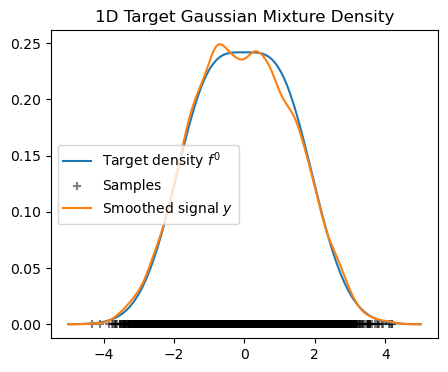

In [7]:
# Display the target density and the samples

# grid on which the density is computed
sigma_max = torch.max(sigmas_target)
xspace = torch.linspace(-1 - 4 * sigma_max, 1 + 4 * sigma_max, 200)

# compute density: log_prob -> exp
Z = target_gmm.log_prob(xspace.unsqueeze(1)).exp().detach()
observed_gmm = make_diagonal_gmm(
    torch.ones(n_samples) / n_samples, samples.view(-1, 1), tau * torch.ones(n_samples, 1)
)
observed_signal = observed_gmm.log_prob(xspace.unsqueeze(1)).exp().detach()

# plot
plt.figure(figsize=(5, 4))
plt.plot(xspace, Z, label=r"Target density $f^0$")
plt.scatter(
    samples, torch.zeros(n_samples), marker="+", color="black", alpha=0.5, label="Samples"
)
plt.plot(xspace, observed_signal, label=r"Smoothed signal $y$")
plt.title("1D Target Gaussian Mixture Density")
plt.legend()
plt.show()

In [8]:
model = DiagonalGMMBlasso(kappa=kappa, y=samples, tau=tau)

# Target
with torch.no_grad():
    positions_target = torch.cat([means_target, sigmas_target], dim=1)
    particles_target = Particles(
        positions=positions_target,
        weights=weights_target,
    )
    model_eval_target = model(particles_target.clone())
    model_eval_target.transform_weights_a_to_omega()
    loss_target = model_eval_target.loss()

# Initialization
positions_init = torch.stack(
    [torch.tensor([2.0, -2.0, 0]), torch.ones(3) * 1.0], dim=-1
)
# try with torch.tensor([1., -1., 0]) for the means - then a particle stays in the middle # TODO garder ça ?
weights_init = torch.ones(3) * 1 / 3

c:\Users\roman\Desktop\these\code\blasso_gmm_cpgd\methods.py:390: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  if torch.isnan(torch.tensor(current_loss)):


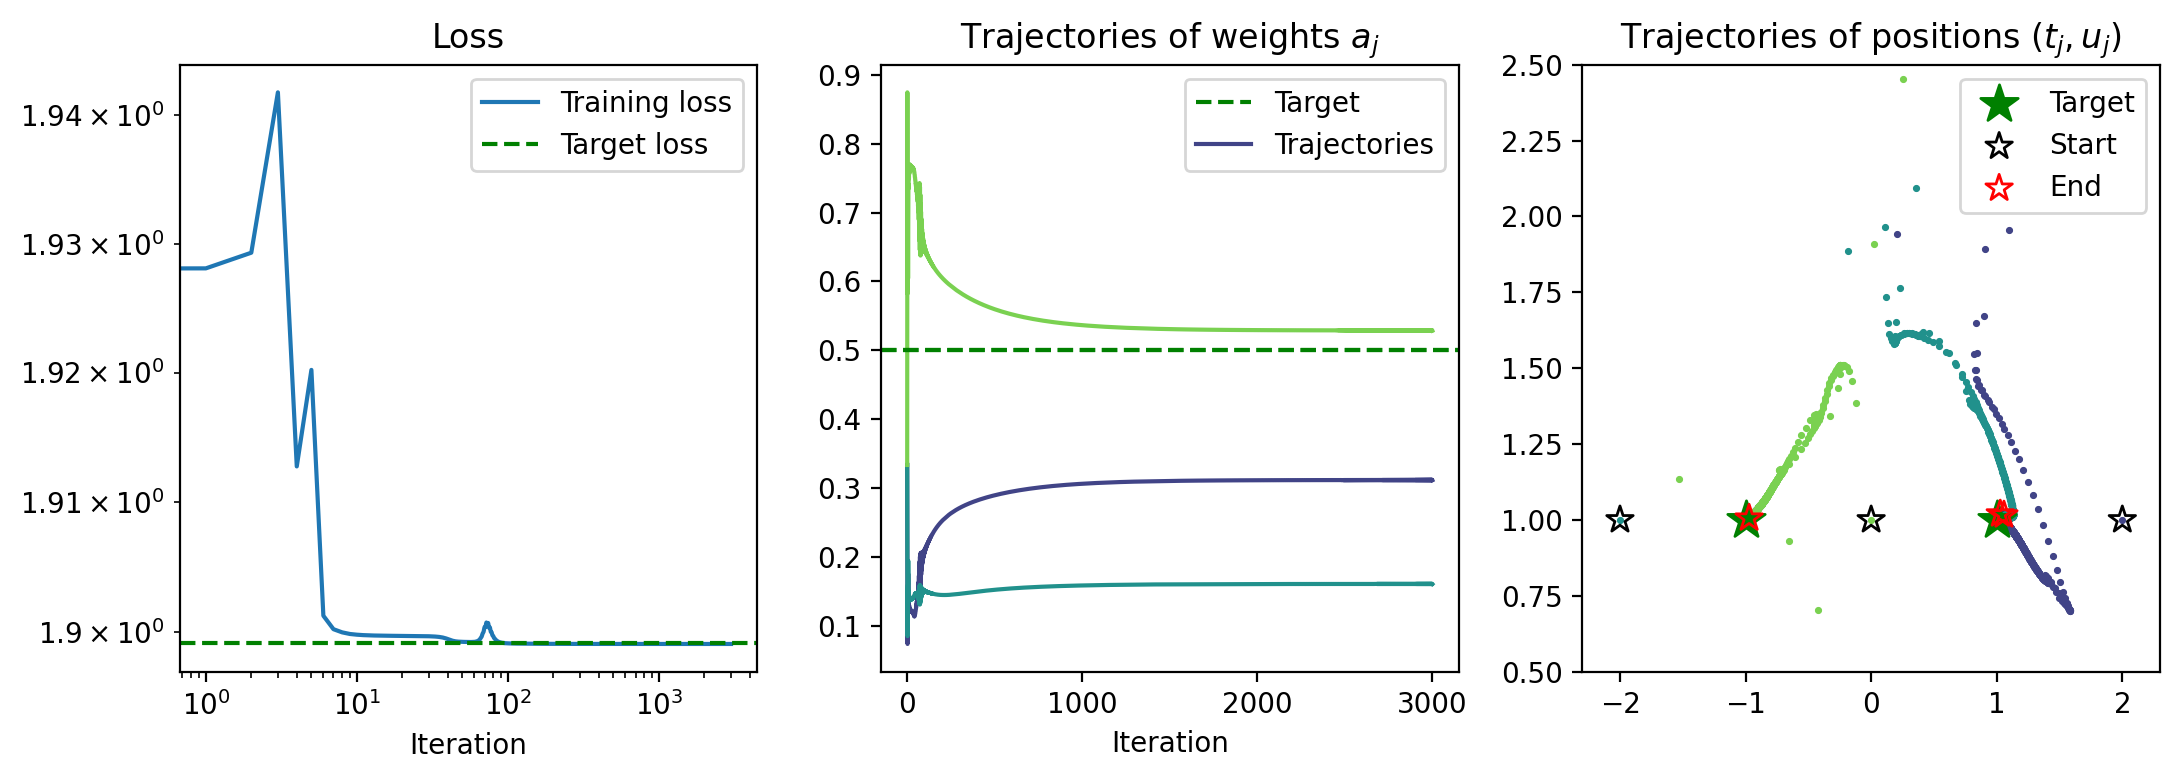

In [9]:
iter_loss, iter_particles = adagrad_conic_optim(
    model=model,
    positions_init=positions_init,
    weights_init=weights_init,
    n_iter=3000,
    eta=1.0,
    store_history=True,
)

plot_all_1d(
    iter_loss, iter_particles, loss_target, means_target, sigmas_target, weights_target, lim_axis=[-2.3,2.3,0.5,2.5]
)

In [10]:
print_scores_W1_KL_likelihood(positions_target,
                              weights_target,
                              iter_particles[-1, :, :-1],
                              iter_particles[-1, :, -1],
                              samples,
                              n_samples_KL=10000,
                              seed_KL=54321)


Scores
----------------------------------------
W1 scores:
  semi-distance  :     0.0638
  Fisher-Rao     :     0.0592
  Euclidean      :     0.0906
----------------------------------------
Train log-likelihood     :      -1.76
Approx. KL divergence    :   0.000834
----------------------------------------


# Comparison with EM

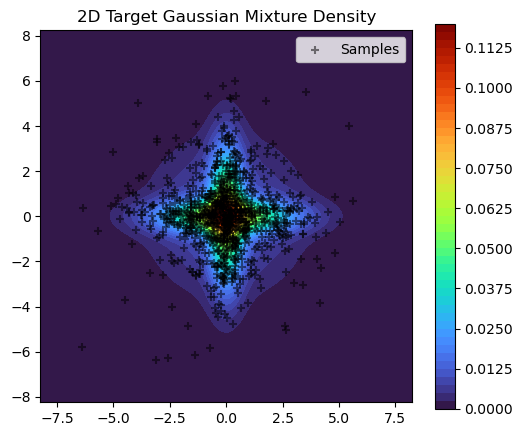

In [11]:
# Set target parameters
means_target = torch.tensor([[0.0, 0.0], [0.0, 0.0], [0.0, 0.0]])
# square roots of the diagonal elements of the covariance matrices
sigma1 = 2.0
sigma2 = 0.5
weight_cross = 2/3
sigma3 = (sigma1**2+sigma2**2)**0.5 #sqrt of value of the global variance of the cross
sigmas_target = torch.tensor([[sigma2, sigma1], [sigma1, sigma2], [sigma3, sigma3]])
sigma_max=torch.max(sigmas_target)
weights_target = torch.tensor([weight_cross/2, weight_cross/2, 1-weight_cross])

# Draw n_samples from target_gmm
n_samples = 1000
target_gmm = make_diagonal_gmm(weights_target, means_target, sigmas_target)
seed = 1234
torch.manual_seed(seed)
samples = target_gmm.sample((n_samples,))


# Display the target density and the samples
# grid on which the density is computed
xspace = torch.linspace(- 4 * sigma_max, 4 * sigma_max, 200)
yspace = torch.linspace(- 4 * sigma_max, 4 * sigma_max, 200)
X, Y = torch.meshgrid(xspace, yspace, indexing="xy")
XY = torch.stack([X, Y], dim=-1)  # shape: [200,200,2]
# compute density: log_prob -> exp
Z = target_gmm.log_prob(XY).exp().detach()
# plot
fig, ax = plt.subplots(figsize=(6, 5))
cs = ax.contourf(X, Y, Z, levels=50, cmap="turbo")
ax.scatter(
    samples[:, 0], samples[:, 1], marker="+", color="black", alpha=0.5, label="Samples"
)
ax.set_title("2D Target Gaussian Mixture Density")
ax.set_aspect("equal", adjustable="box")
ax.legend()
fig.colorbar(cs)
plt.show()

In [12]:
kappa = 0.01
tau = 0.6 # avec 0.2 et 500 samples, ne trouve que 2 composantes. 0.5 mieux
model = DiagonalGMMBlasso(kappa=kappa, y=samples, tau=tau)

# Target
with torch.no_grad():
    positions_target = torch.cat([means_target, sigmas_target], dim=1)
    particles_target = Particles(
        positions=positions_target, weights=weights_target
    )
    model_eval_target = model(particles_target.clone())
    model_eval_target.transform_weights_a_to_omega()
    loss_target = model_eval_target.loss()

# Initialization
def points_on_circle(r, n):
    """
    Returns n points on a circle of radius r as a tensor of shape (n, 2).
    """
    l = torch.arange(0, n)
    angles = 2 * torch.pi / n * l
    x = r * torch.cos(angles)
    y = r * torch.sin(angles)
    return torch.stack([x, y], dim=1)

n_particles = 10  # try 3, 4, 5, 10 with radius 1  # Number of particles
means_init = points_on_circle(1.0, n_particles)
sigmas_init = torch.ones((n_particles,2))*0.5
positions_init = torch.cat([means_init, sigmas_init], dim=1)
weights_init = torch.ones(n_particles)*1/n_particles

c:\Users\roman\Desktop\these\code\blasso_gmm_cpgd\methods.py:390: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  if torch.isnan(torch.tensor(current_loss)):


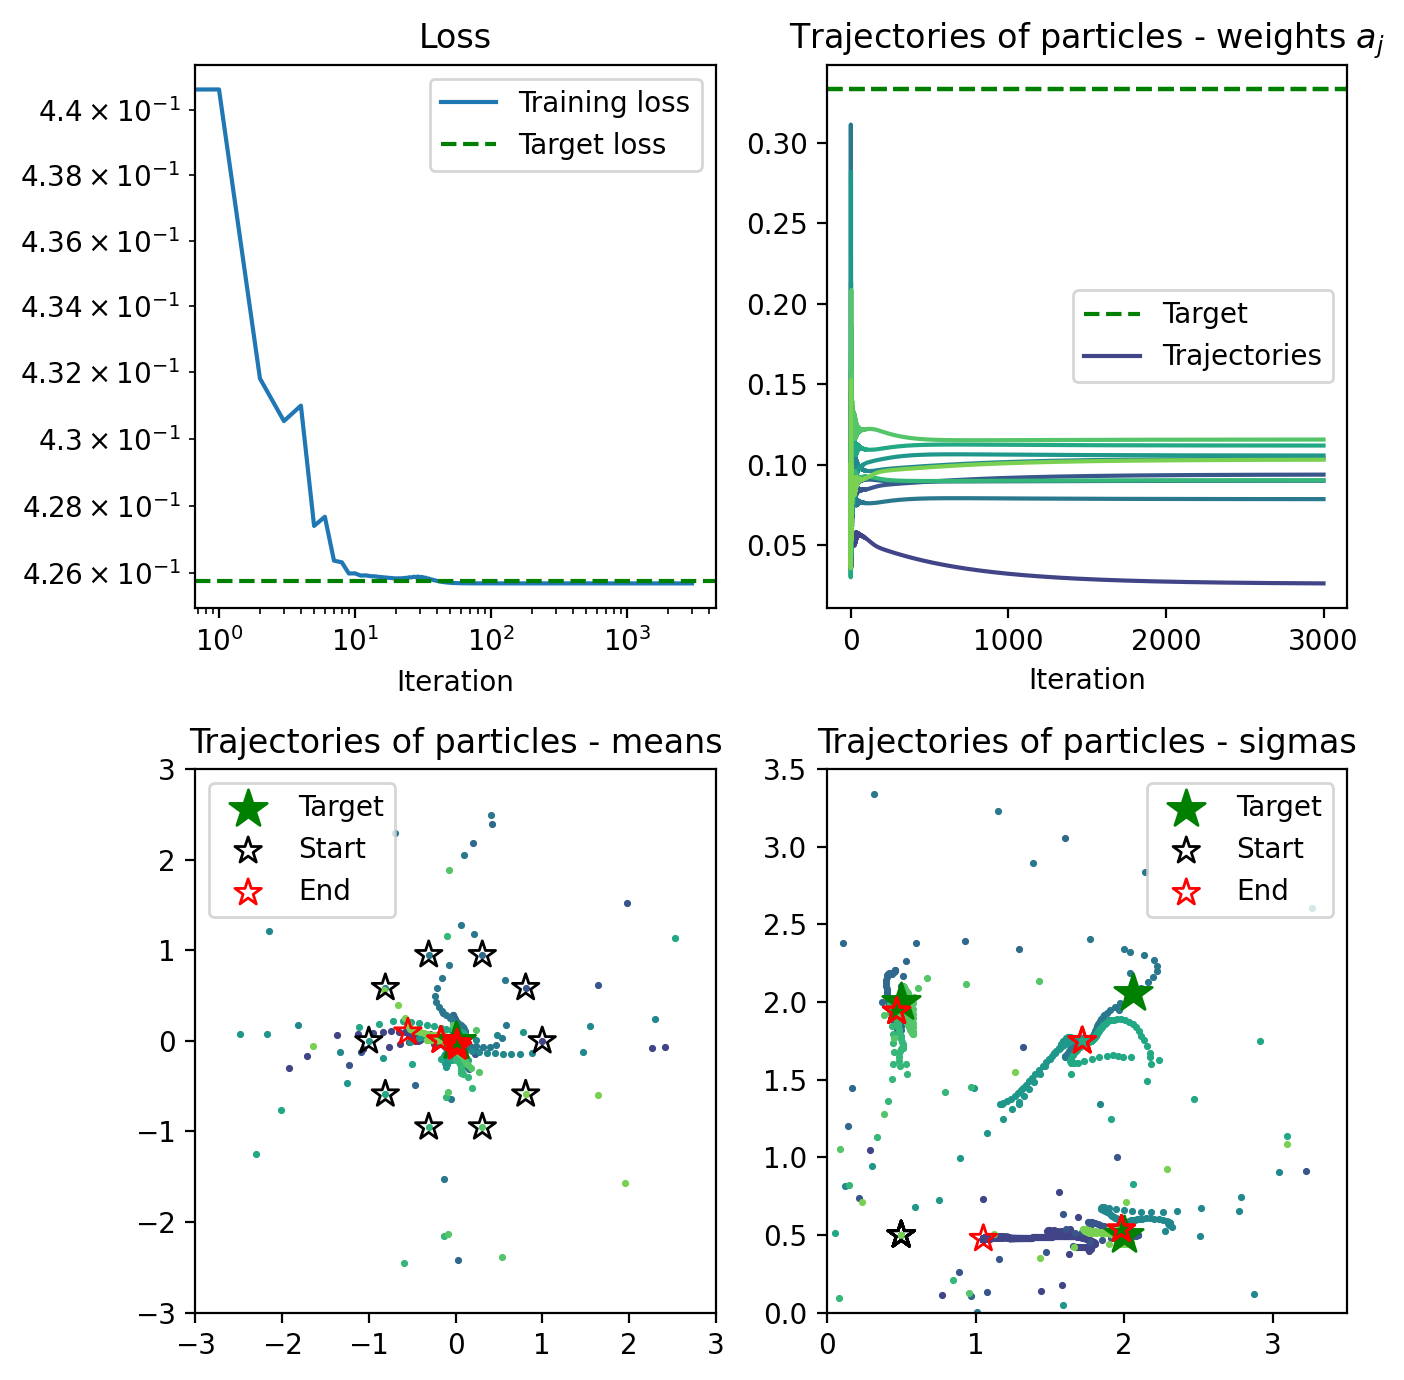

In [25]:
iter_loss, iter_particles = adagrad_conic_optim(
    model=model,
    positions_init=positions_init,
    weights_init=weights_init,
    n_iter=3000,
    eta=1.0,
    store_history=True,
)

plot_all_2d(iter_loss, iter_particles, loss_target, means_target, sigmas_target, weights_target,
            lim_axis_t=[-3,3,-3,3], lim_axis_u=[0,3.5,0,3.5])

In [26]:
print_scores_W1_KL_likelihood(positions_target,
                              weights_target,
                              iter_particles[-1, :, :-1],
                              iter_particles[-1, :, -1],
                              samples,
                              n_samples_KL=10000,
                              seed_KL=54321)


Scores
----------------------------------------
W1 scores:
  semi-distance  :      0.128
  Fisher-Rao     :      0.131
  Euclidean      :      0.279
----------------------------------------
Train log-likelihood     :      -3.66
Approx. KL divergence    :      0.028
----------------------------------------


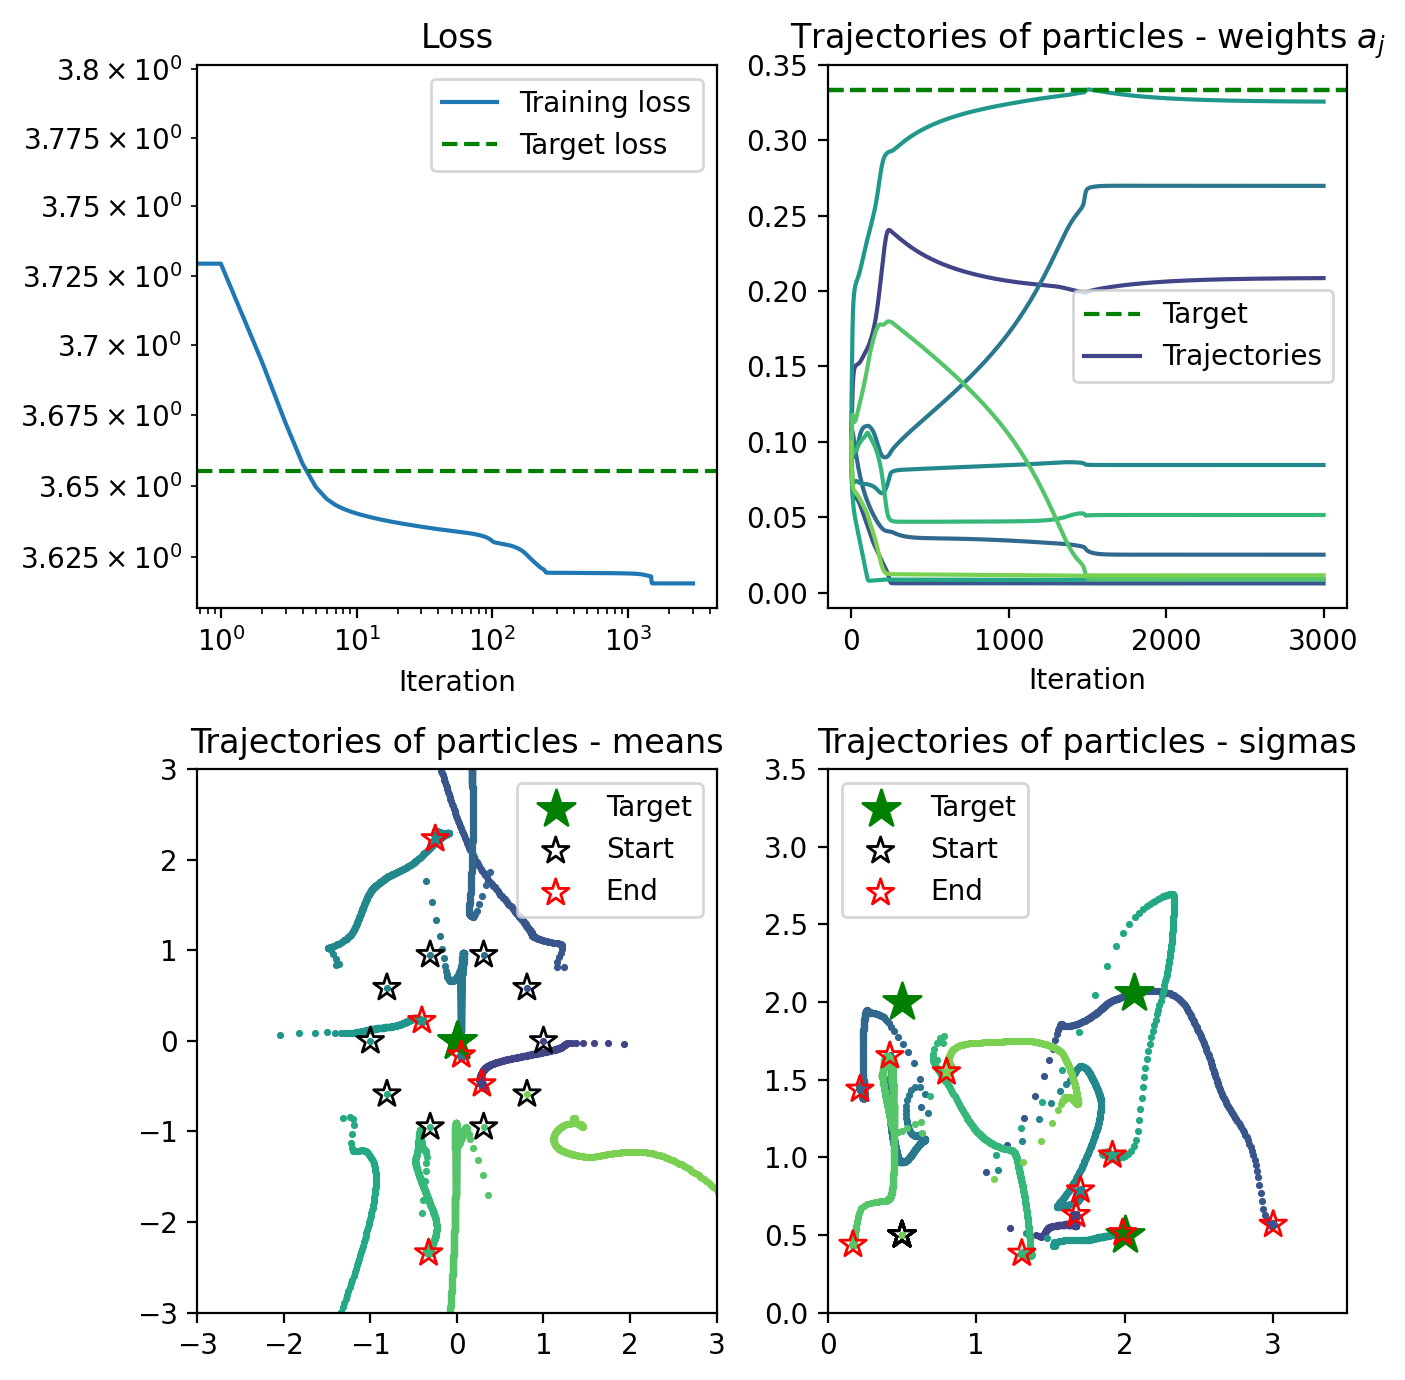

In [27]:
iter_loss_em, iter_particles_em = em_optim(samples=samples,
                            means_init=means_init,
                            sigmas_init=sigmas_init,
                            weights_init=weights_init,
                            n_iter=3000,
                            store_history=True
                            )
loss_target_em=-target_gmm.log_prob(samples).mean()

# to plot the loss (minus the log-likelihood) in log log scale, we need positive values
loss_em_shift = torch.min(torch.tensor([-1e-15, torch.min(iter_loss_em), loss_target_em]))
plot_all_2d((iter_loss_em+loss_em_shift)[1:], iter_particles_em, loss_target_em+loss_em_shift, means_target, sigmas_target, weights_target,
            lim_axis_t=[-3,3,-3,3], lim_axis_u=[0,3.5,0,3.5])

In [16]:
print_scores_W1_KL_likelihood(positions_target,
                              weights_target,
                              iter_particles_em[-1, :, :-1],
                              iter_particles_em[-1, :, -1],
                              samples, 
                              n_samples_KL=10000,
                              seed_KL=54321)


Scores
----------------------------------------
W1 scores:
  semi-distance  :      0.639
  Fisher-Rao     :      0.667
  Euclidean      :       1.21
----------------------------------------
Train log-likelihood     :      -3.62
Approx. KL divergence    :      0.055
----------------------------------------


# Separation between components 

**Goal**: To test the influence on the separation of components and of the sample size on the convergence of the algorithm.

**Experimental design:**
* Target: GMM in dimension $d=1$, with 2 spikes of weights $\frac{1}{2},\frac{1}{2}$, and positions $x_1^0=(-1,u^0), x_2^0=(1,u^0)$. 
* Observation: sample of size $n$.

We test convergence for various $u^0$ and $n$. As $u^0$ gets larger, the separation between components gets smaller (another possibility would be to fix the variances and to bring the means closer).
For the optimization, we use Adagrad with natural gradients.

**Scores:**
* We run the algorithm with several initializations (3) and keep the results corresponding to the smallest loss.

* The results are aggregated over 10 samples (mean or median). We measure the recovery using a Wasserstein (semi) distance on the positions which requires the normalization of the estimated weights $\hat{a}_j$: 

$$ 
S_x =\min_{\substack{\gamma_{ij}\geq 0, \\ \sum_j \gamma_{ij} = a_i^0,  \\ \sum_i \gamma_{ij} = \frac{\hat{a}_j}{\sum_j \hat{a}_j}}} \sum_{ij} \gamma_{ij} d(x_i^0,\hat{x}_j)\,.
$$ 

Here $d$ is a (semi) distance that does not depend on $\tau$. It can be chosen as the semi-distance $d_0$ defined by $d_0(x,x')^2 = \frac{(t-t')^2}{u^2+u'^2} + \ln\left( \frac{u^2 + u'^2}{2u u'}\right)$, or the Fisher-Rao distance $\mathfrak{d}_{\mathfrak{g}0}(x,x') = \sqrt{2} \ln\left(\frac{\sqrt{(t-t')^2 + (u-u')^2} + \sqrt{(t-t')^2 + (u+u')^2}}{2\sqrt{u u'}} \right)$, or the Euclidean distance.

* We perform cross validation to select the best hyperparameters $\tau,\kappa$, using the score $S_x$.

We ran the script `run_grid_search.py`.
The results are stored in the file `results_grid_search.pkl` (available upon request).
This file contains the outcomes of 720000 optimizations, stored as a list of entries of the form
`[((u0, seed, tau, kappa, init, n_samples), (scores, loss)), ...]`.

Each entry corresponds to a single optimization, identified by the tuple
`(u0, seed, tau, kappa, init, n_samples)`.

* `seed`: random seed
* `n_samples`: size of the sample used
* `u0`: standard deviation of the target particles
(a sample is specified by `u0`, `n_samples`, and `seed`)
* `init`: algorithm initialization
* `tau`, `kappa`: algorithm hyperparameters
* `scores`: dictionary of the form `{"Fisher-Rao": ..., "Euclidean": ..., "semi-distance": ...}`
* `loss`: value of the objective function associated with the optimization (this function depends on kappa, tau, and the sample).

## Post-processing

In [17]:
# Post-processing:
# 1 - results selectionned over the initializations (smallest loss),
# 2 - then aggregated (average or median) score over samples (several seeds)
# 3 - then selection of the best (smallest) score over tau, kappa (several scores depending on the distance used in S_x)
# final result: best (aggregated) score, best tau, best kappa wrt. u0, n_samples, and the distance used.


def postprocess_results(
    results,
    return_selected=True,
    return_aggregated=True,
    return_best=True,
    aggregate="average",
):
    """
    results : list
        Output of parallel computation:
        [ ((u0, seed, tau, kappa, init, n_samples), (scores, loss)), ... ]

    return_selected : bool
        Return result corresponding to the best init (= smallest loss) per (u0, n_samples, seed, tau, kappa)

    return_aggregated : bool
        Return average or median over samples (seeds)

    return_best : bool
        Return best (tau, kappa) per (u0, n_samples, distance)
    """
    if aggregate not in ["median", "average"]:
        raise ValueError("aggregate must be 'median' or 'average'")

    # 1 - Select best init
    selected = {}

    for (u0, seed, tau, kappa, init, n_samples), (scores, loss) in results:
        key = (u0, n_samples, seed, tau, kappa)
        if key not in selected or loss < selected[key][1]:
            selected[key] = (scores, loss)

    selected = {k: v[0] for k, v in selected.items()}

    # 2 - Average or median over seeds
    aggregated = {}

    for (u0, n_samples, seed, tau, kappa), scores in selected.items():
        key = (u0, n_samples, tau, kappa)

        if key not in aggregated:
            aggregated[key] = {}
            for d, v in scores.items():
                aggregated[key][d] = [float(v)]
                aggregated[key][d] = [float(v)]
        else:
            for d, v in scores.items():
                aggregated[key][d].append(float(v))

    for key, tab_scores in aggregated.items():
        for d, values in tab_scores.items():
            if aggregate == "median":
                tab_scores[d] = torch.quantile(torch.tensor(values), 0.5).item()
            if aggregate == "average":
                tab_scores[d] = torch.mean(torch.tensor(values)).item()

    # 3 - Select best tau, kappa
    best = {}

    for (u0, n_samples, tau, kappa), scores in aggregated.items():
        for dist, value in scores.items():
            key = (u0, n_samples, dist)

            if key not in best or value < best[key][2]:
                best[key] = (tau, kappa, value)

    best = {key: (tau, kappa, score) for key, (tau, kappa, score) in best.items()}

    # Return what the user asked for
    outputs = []
    if return_selected:
        outputs.append(selected)
    if return_aggregated:
        outputs.append(aggregated)
    if return_best:
        outputs.append(best)

    return outputs

In [18]:
# Plotting functions
def plot_tab_values(
    tab_yaxis,
    tab_xaxis,
    tab_values,
    label_y,
    label_x,
    title,
    inch_per_cell=0.5,
    name_value="score",
    highlight_min=False,
):
    """
    if tab_yaxis is of size L and tab_xaxis of size l,
    tab_values should be of size L*l, and should contain positive values
    """
    cbar_width = 0.15
    gap_width = 0.15

    nrows, ncols = tab_values.shape

    img_w = ncols * inch_per_cell
    img_h = nrows * inch_per_cell

    total_w = img_w + gap_width + cbar_width

    fig = plt.figure(figsize=(total_w, img_h), dpi=200)

    # GridSpec with 3 columns (image | gap | colorbar)
    gs = GridSpec(1, 3, left=0, right=1, bottom=0, top=1, wspace=0)

    ax = fig.add_subplot(gs[0, 0])
    gap = fig.add_subplot(gs[0, 1])  # empty spacer
    cax = fig.add_subplot(gs[0, 2])
    gap.axis("off")
    ax.set_position([0, 0, img_w / total_w, 1])
    gap.set_position([img_w / total_w, 0, gap_width / total_w, 1])
    cax.set_position([(img_w + gap_width) / total_w, 0, cbar_width / total_w, 1])

    vmin = torch.min(tab_values)  # attention: LogNorm needs >0
    vmax = torch.max(tab_values)
    assert vmin > 0, (
        "plot_tab_values: tab_values must contain only strictly positive values "
        "when using a log-scaled colormap."
    )

    im = ax.imshow(
        tab_values,
        origin="lower",
        aspect="auto",
        cmap="viridis",
        norm=colors.LogNorm(vmin=vmin, vmax=vmax),
    )
    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label(name_value, labelpad=10)

    ax.set_xticks(range(len(tab_xaxis)))
    ax.set_xticklabels([f"{x:.1e}" for x in tab_xaxis], rotation=90)
    ax.set_yticks(range(len(tab_yaxis)))
    ax.set_yticklabels([f"{y:.1e}" for y in tab_yaxis])

    for i in range(len(tab_yaxis)):
        for j in range(len(tab_xaxis)):
            ax.text(
                j, i, f"{tab_values[i, j]:.2g}", ha="center", va="center", fontsize=8
            )

    if highlight_min:
        flat_min_idx = torch.argmin(tab_values)
        min_i, min_j = torch.unravel_index(flat_min_idx, tab_values.shape)
        rect = Rectangle(
            (min_j - 0.5, min_i - 0.5),
            1.0,
            1.0,
            fill=False,
            edgecolor="white",
            linewidth=2.5,
        )
        ax.add_patch(rect)

    ax.set_xlabel(label_x)
    ax.set_ylabel(label_y)
    ax.set_title(title)

    plt.show()


def plot_best_results(best_results, nb_u0=None):
    u0_vals = sorted({u0 for (u0, n, dist) in best_results})

    n_vals = sorted({n for (u0, n, dist) in best_results})
    dists = sorted({dist for (u0, n, dist) in best_results})

    u0_index = {u0: i for i, u0 in enumerate(u0_vals)}
    n_index = {n: i for i, n in enumerate(n_vals)}
    dist_index = {dist: i for i, dist in enumerate(dists)}

    tab_scores = torch.zeros(len(u0_vals), len(n_vals), len(dists))

    for (u0, n, d), (tau, kappa, score) in best_results.items():
        i = u0_index[u0]
        j = n_index[n]
        k = dist_index[d]
        tab_scores[i, j, k] = score

    cmap = cm.get_cmap("turbo", len(u0_vals))
    colors = [cmap(i) for i in range(len(u0_vals))]

    for k, dist in enumerate(dists):
        plt.figure(figsize=(8, 4), dpi=200)

        for i, (u0, color) in enumerate(zip(u0_vals, colors)):
            if nb_u0 is not None and i > nb_u0 - 1:
                break
            plt.loglog(
                n_vals,
                tab_scores[i, :, k],
                marker="o",
                label=rf"$u^0={u0:.2g}$",
                color=color,
                alpha=0.7,
            )

        plt.xlabel(r"$n$")
        plt.ylabel("score")
        plt.title(f"Best aggregated score vs $n$ ({dist})")
        plt.grid(True, which="both", ls="--", alpha=0.4)
        plt.legend(
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
            borderaxespad=0.0,
        )

        plt.tight_layout(rect=[0, 0, 0.8, 1])
        plt.show()


def plot_best_tau_kappa(best_results):
    """
    Plot best tau and best kappa depending on u0, n_samples and distance.

    Parameters
    ----------
    best_results : dict
        Keys: (u0, n_samples, dist)
        Values: (best_tau, best_kappa, best_score)
    """

    # Collect axes
    u0_vals = sorted({u0 for (u0, n, d) in best_results})
    n_vals = sorted({n for (u0, n, d) in best_results})
    dists = sorted({d for (u0, n, d) in best_results})

    u0_index = {u0: i for i, u0 in enumerate(u0_vals)}
    n_index = {n: j for j, n in enumerate(n_vals)}

    for dist in dists:
        # Allocate tables for this distance
        tab_tau = torch.zeros(len(u0_vals), len(n_vals))
        tab_kappa = torch.zeros(len(u0_vals), len(n_vals))

        # Fill tables
        for (u0, n, d), (tau, kappa, score) in best_results.items():
            if d != dist:
                continue
            i = u0_index[u0]
            j = n_index[n]
            tab_tau[i, j] = tau
            tab_kappa[i, j] = kappa

        # Plot tau
        plot_tab_values(
            tab_yaxis=u0_vals,
            tab_xaxis=n_vals,
            tab_values=tab_tau,
            label_y=r"$u^0$",
            label_x=r"$n$",
            title=f"Best $\\tau$ for {dist}",
            name_value=r"$\tau$",
        )

        # Plot kappa
        plot_tab_values(
            tab_yaxis=u0_vals,
            tab_xaxis=n_vals,
            tab_values=tab_kappa,
            label_y=r"$u^0$",
            label_x=r"$n$",
            title=f"Best $\\kappa$ for {dist}",
            name_value=r"$\kappa$",
        )


def plot_variance_scores(selected_results, best_results, u0_vals, n):
    dists = sorted({dist for (_, _, dist) in best_results})

    fig, axes = plt.subplots(
        1, len(dists), figsize=(len(u0_vals) * 0.7 * len(dists), 4), sharey=False, dpi=200
    )

    if len(dists) == 1:
        axes = [axes]

    for ax, dist in zip(axes, dists):
        for i, u0 in enumerate(u0_vals):
            if (u0, n, dist) not in best_results:
                continue

            best_tau, best_kappa, best_agg = best_results[(u0, n, dist)]

            ys = [
                scores[dist]
                for (u0_, n_, seed, tau, kappa), scores in selected_results.items()
                if u0_ == u0
                and n_ == n
                and tau == best_tau
                and kappa == best_kappa
                and dist in scores
            ]

            # seed-wise cloud
            x_spacing = 1 / 2
            x = torch.linspace(i * x_spacing - 0.05, i * x_spacing + 0.05, len(ys))
            ax.scatter(x, ys, s=20)

            # aggregated score
            ax.plot(
                [i * x_spacing - 0.1, i * x_spacing + 0.1],
                [best_agg, best_agg],
                color="black",
                lw=2,
            )

        ax.set_title(dist)
        ax.set_xticks([i * x_spacing for i in range(len(u0_vals))])
        ax.set_xticklabels([rf"${u0:.2g}$" for u0 in u0_vals])
        ax.grid(True, axis="y", alpha=0.3)
        ax.set_xlabel(r"$u^0$")

    axes[0].set_ylabel("score")
    fig.suptitle(rf"$n={n:.2g}$", y=1.05)

    legend_elements = [
        Line2D([0], [0], marker="o", linestyle="", markersize=7, label="single run"),
        Line2D([0], [0], color="black", lw=2, label="aggregated score"),
    ]

    fig.legend(
        handles=legend_elements,
        loc="upper center",
        frameon=False,
        ncol=2,
        bbox_to_anchor=(0.8, 1.02),
    )

    plt.tight_layout()
    plt.show()


def plot_tau_kappa_grid_from_aggregated(aggregated_results, u0, n, dist):
    taus = sorted(
        {tau for (u0_, n_, tau, kappa) in aggregated_results if u0_ == u0 and n_ == n}
    )
    kappas = sorted(
        {kappa for (u0_, n_, tau, kappa) in aggregated_results if u0_ == u0 and n_ == n}
    )

    tau_index = {t: i for i, t in enumerate(taus)}
    kappa_index = {k: i for i, k in enumerate(kappas)}

    tab_scores = torch.full((len(taus), len(kappas)), float("nan"))

    for (u0_, n_, tau, kappa), scores in aggregated_results.items():
        if u0_ == u0 and n_ == n and dist in scores:
            i = tau_index[tau]
            j = kappa_index[kappa]
            tab_scores[i, j] = scores[dist]

    plot_tab_values(
        taus,
        kappas,
        tab_scores,
        r"$\tau$",
        r"$\kappa$",
        f"Grid search for $u^0=${u0:.2g}, $n=${n:.2g} — {dist} — aggregated scores",
        inch_per_cell=0.3,
        highlight_min=True,
    )


def plot_tau_kappa_grid_from_selected(
    selected_results,
    u0,
    n_samples,
    seed,
    dist,
    inch_per_cell=0.3,
):
    # collect taus and kappas for the selected configuration
    taus = sorted(
        {
            tau
            for (u0_, n_, seed_, tau, kappa) in selected_results
            if u0_ == u0 and seed_ == seed and n_ == n_samples
        }
    )

    kappas = sorted(
        {
            kappa
            for (u0_, n_, seed_, tau, kappa) in selected_results
            if u0_ == u0 and seed_ == seed and n_ == n_samples
        }
    )

    tau_index = {t: i for i, t in enumerate(taus)}
    kappa_index = {k: i for i, k in enumerate(kappas)}

    tab_scores = torch.full((len(taus), len(kappas)), float("nan"))

    # fill grid
    for (u0_, n_, seed_, tau, kappa), scores in selected_results.items():
        if u0_ == u0 and seed_ == seed and n_ == n_samples and dist in scores:
            i = tau_index[tau]
            j = kappa_index[kappa]
            tab_scores[i, j] = scores[dist]

    plot_tab_values(
        taus,
        kappas,
        tab_scores,
        r"$\tau$",
        r"$\kappa$",
        rf"Grid search for $u^0={u0:.2g}$, "
        rf"$n={n_samples:.2g}$ — {dist} — 1 sample, best initialization",
        inch_per_cell=inch_per_cell,
        highlight_min=True,
    )

## Results

In [19]:
import pickle

with open(r"results_grid_search.pkl", "rb") as f:
    results = pickle.load(f)

print("Recovered", len(results), "entries")

Recovered 720000 entries


C:\Users\roman\AppData\Local\Temp\ipykernel_23192\28500049.py:106: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("turbo", len(u0_vals))


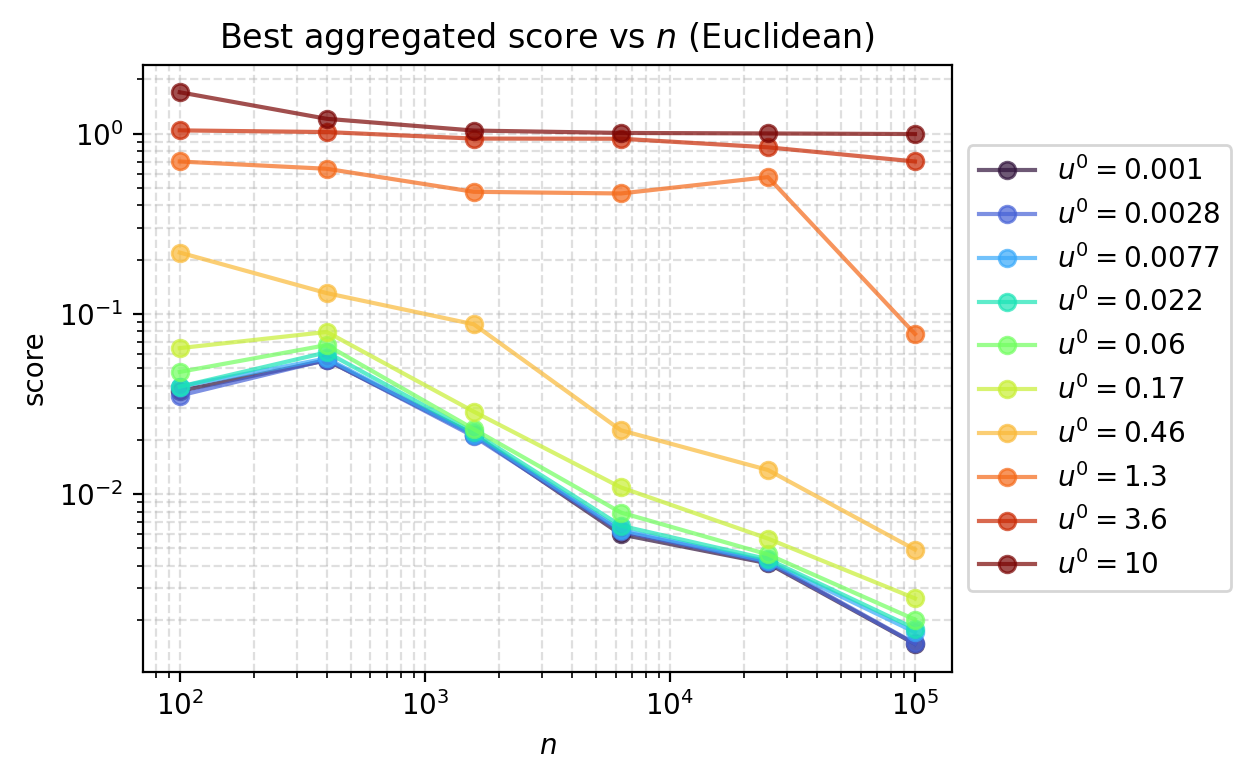

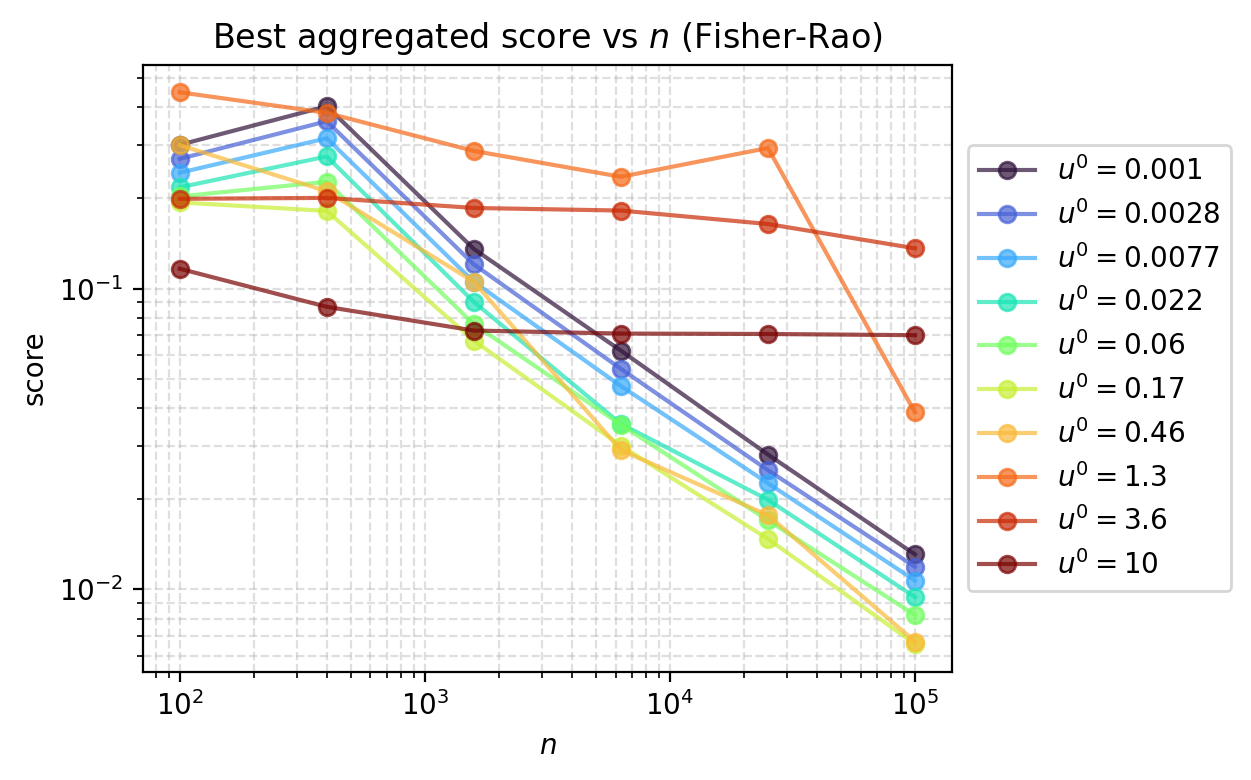

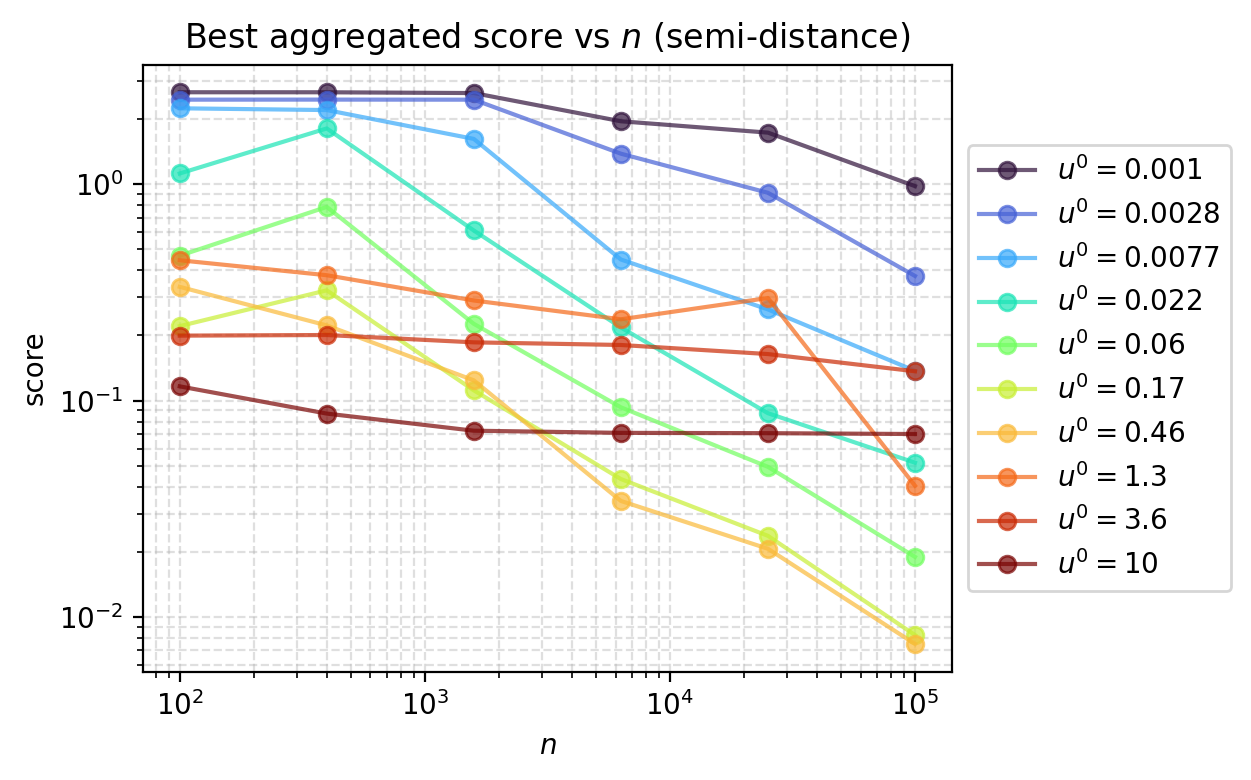

In [20]:
selected_results, aggregated_results, best_results = postprocess_results(
    results,
    return_selected=True,
    return_aggregated=True,
    return_best=True,
    aggregate="median",  # or "average"
)
plot_best_results(best_results, nb_u0=None)  # nb_u0=6 or None

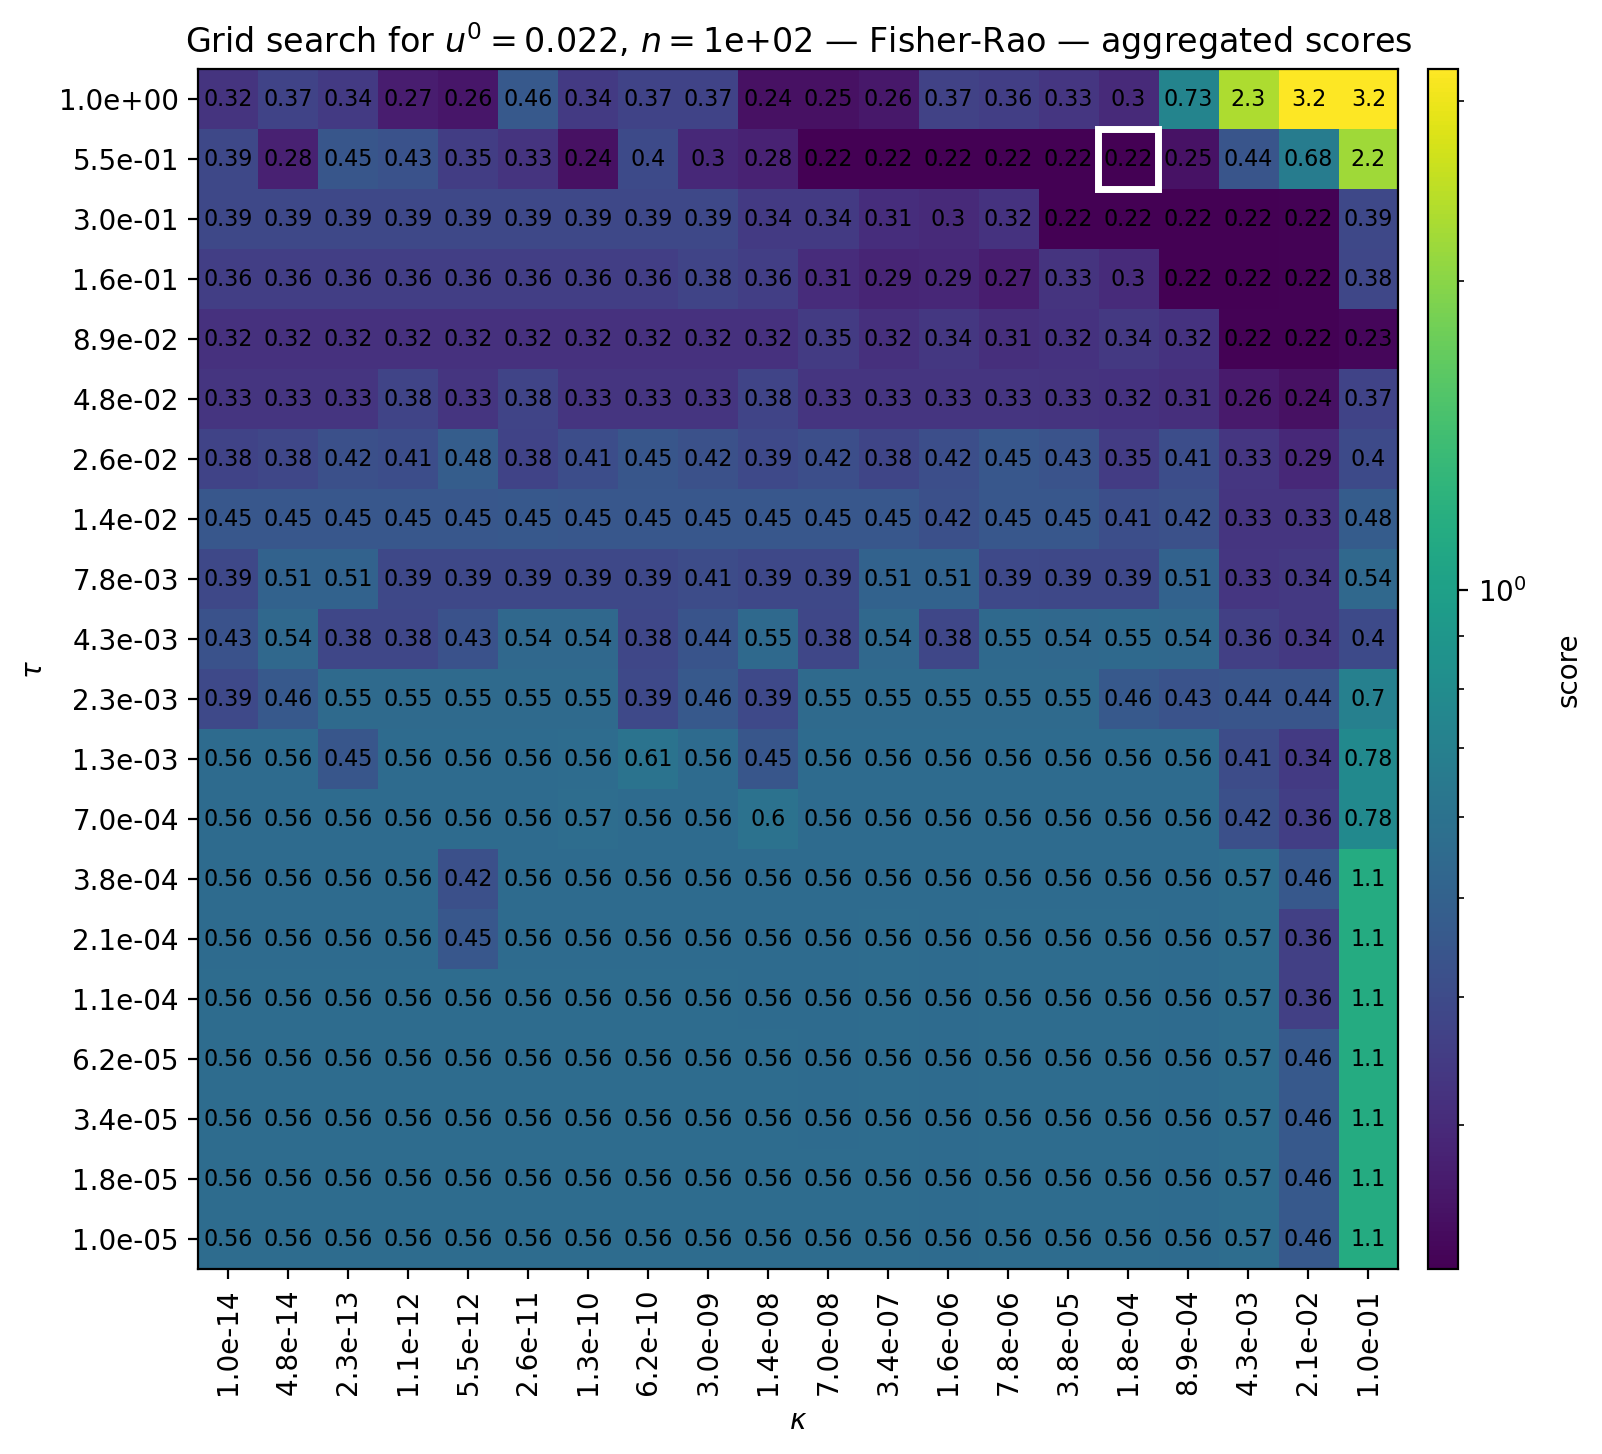

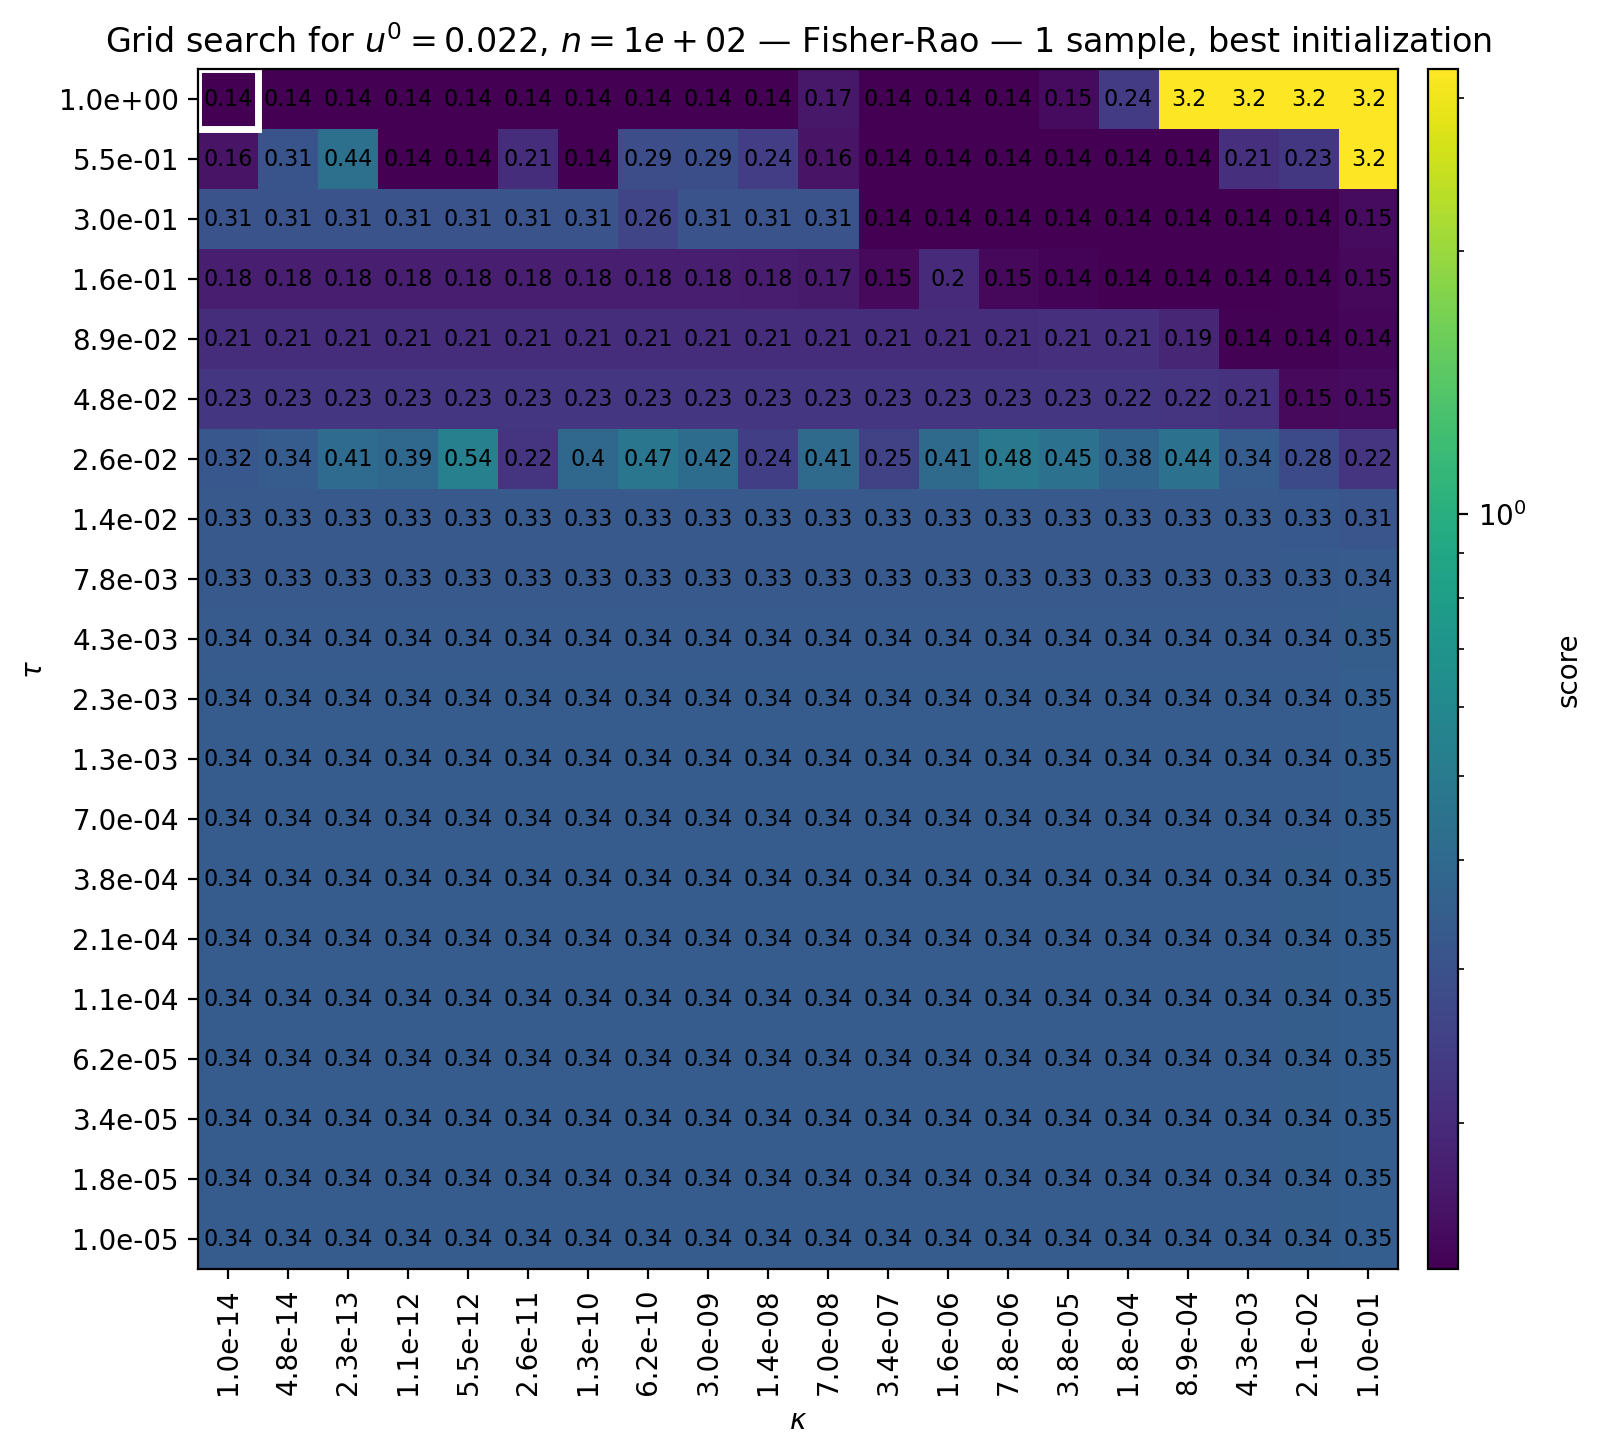

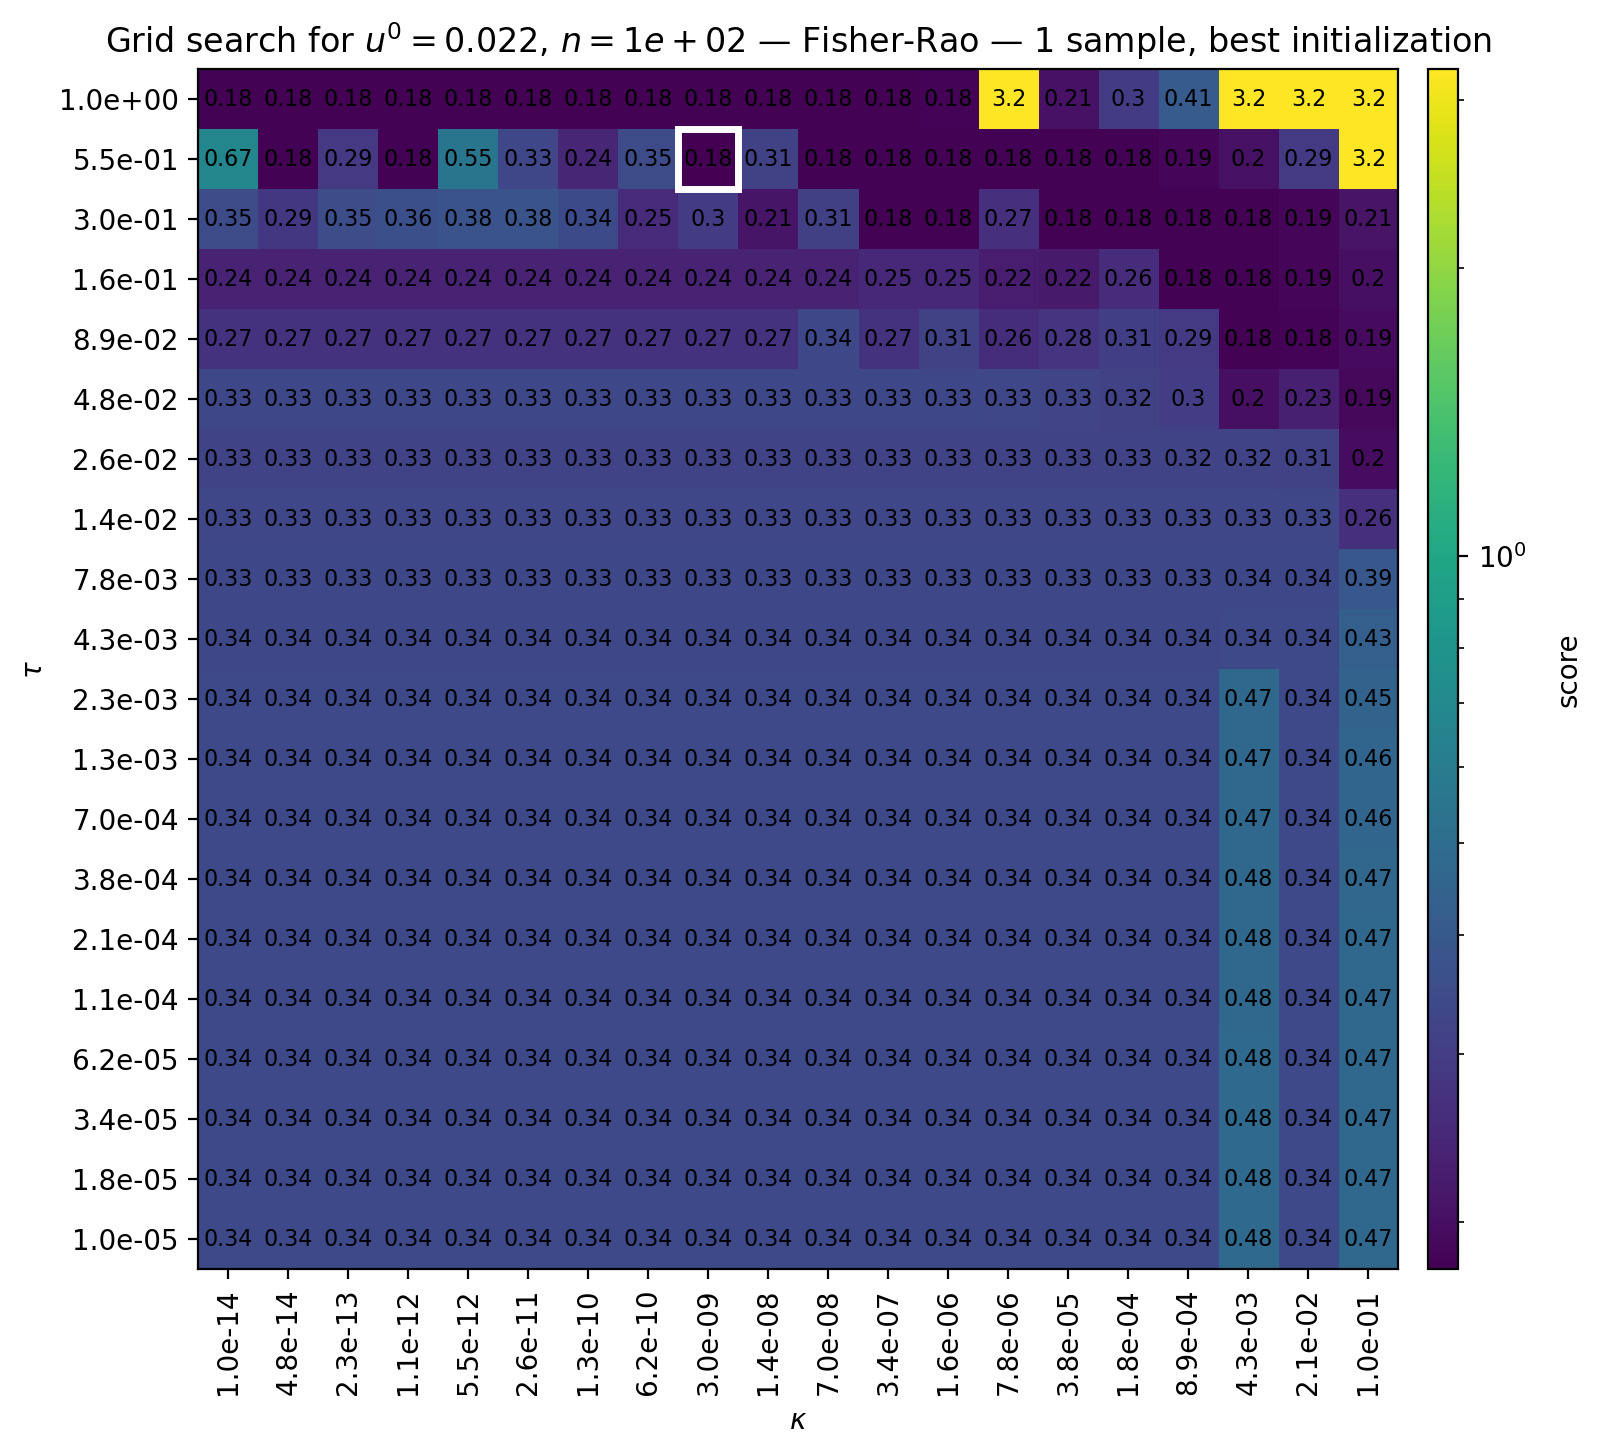

In [21]:
u0 = results[227000][0][0]
n = results[227000][0][5]
plot_tau_kappa_grid_from_aggregated(aggregated_results, u0, n, "Fisher-Rao")

seed = results[227000][0][1]
plot_tau_kappa_grid_from_selected(selected_results, u0, n, seed, "Fisher-Rao")

seed = results[0][0][1]
plot_tau_kappa_grid_from_selected(selected_results, u0, n, seed, "Fisher-Rao")

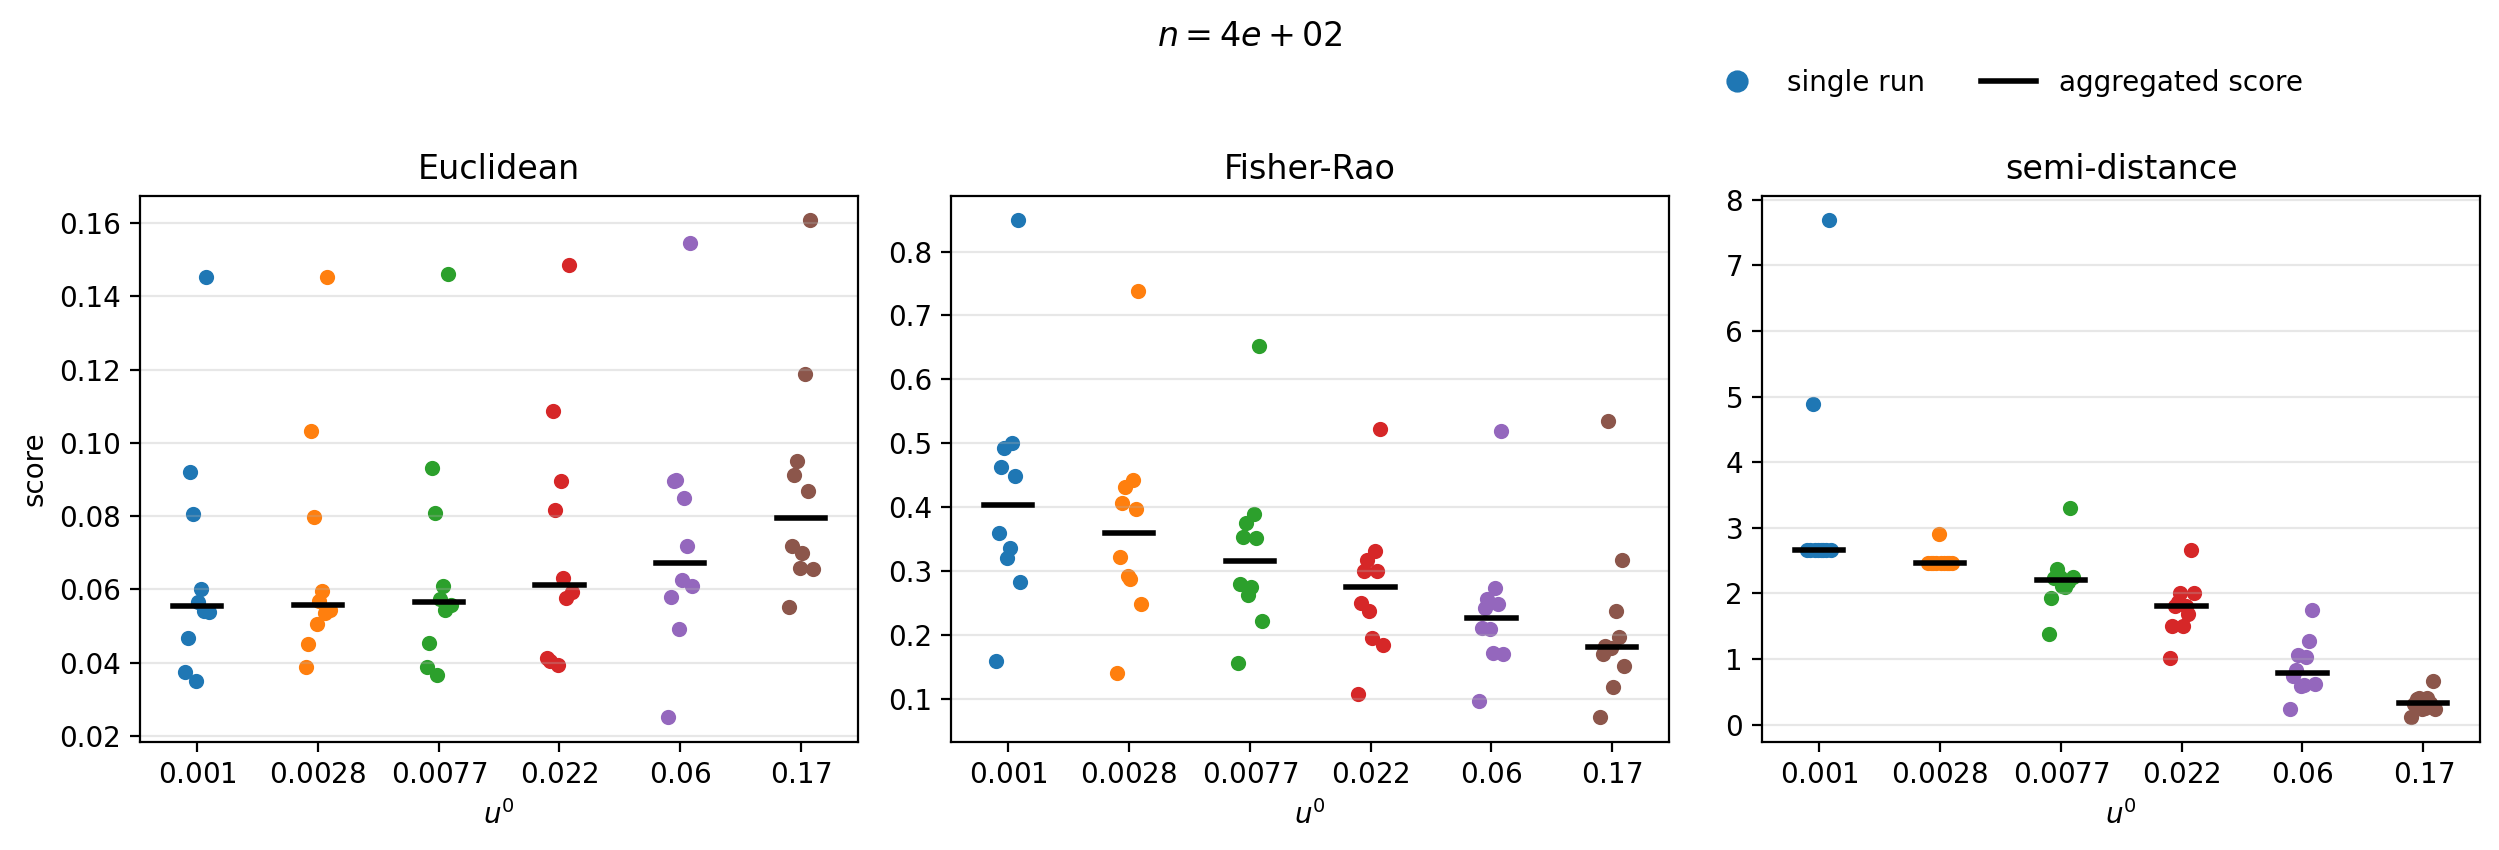

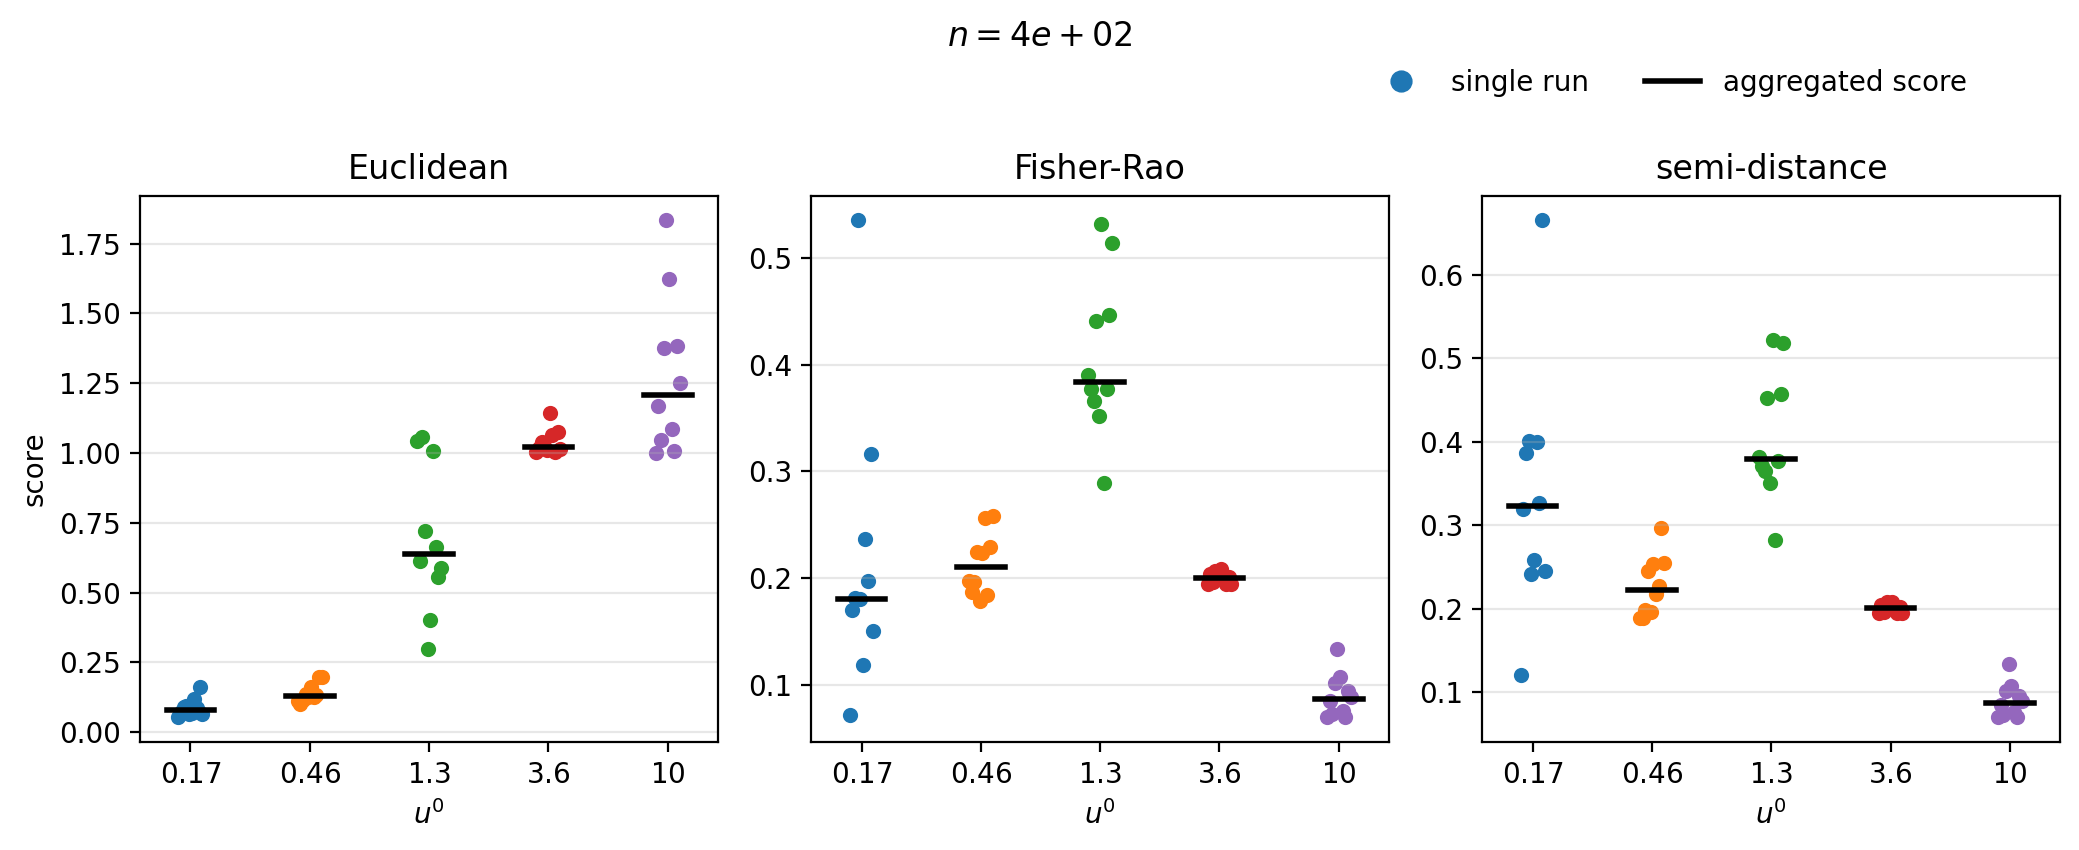

In [22]:
tab_u0 = sorted({u0 for (u0, n, d) in best_results})
n = results[1000][0][5]
plot_variance_scores(
    selected_results, best_results, tab_u0[0:6], n
)  # tab_u0[0:6] ou tab_u0
plot_variance_scores(selected_results, best_results, tab_u0[5:], n)

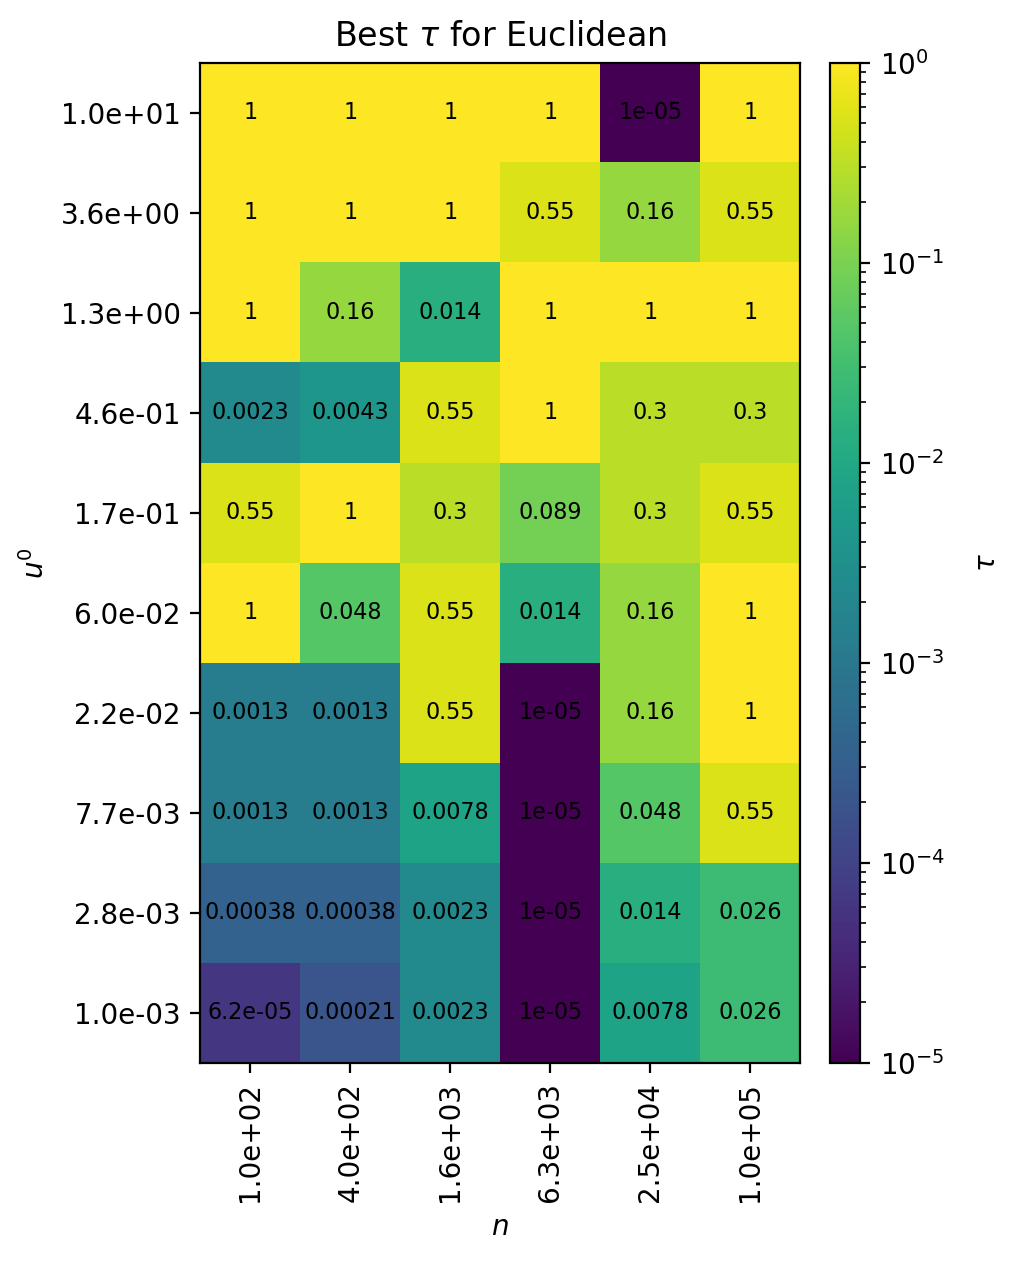

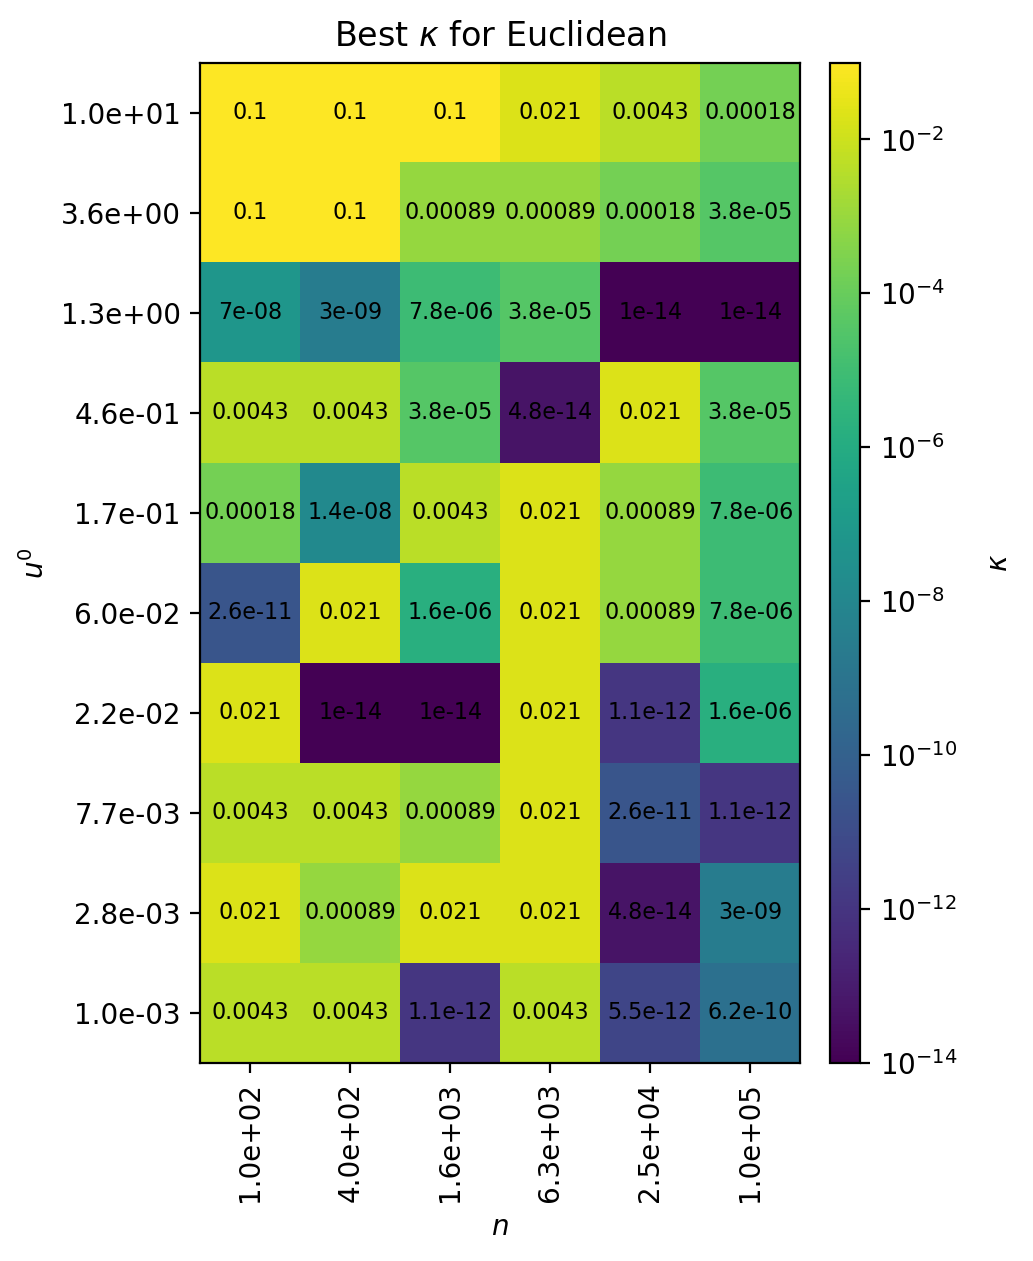

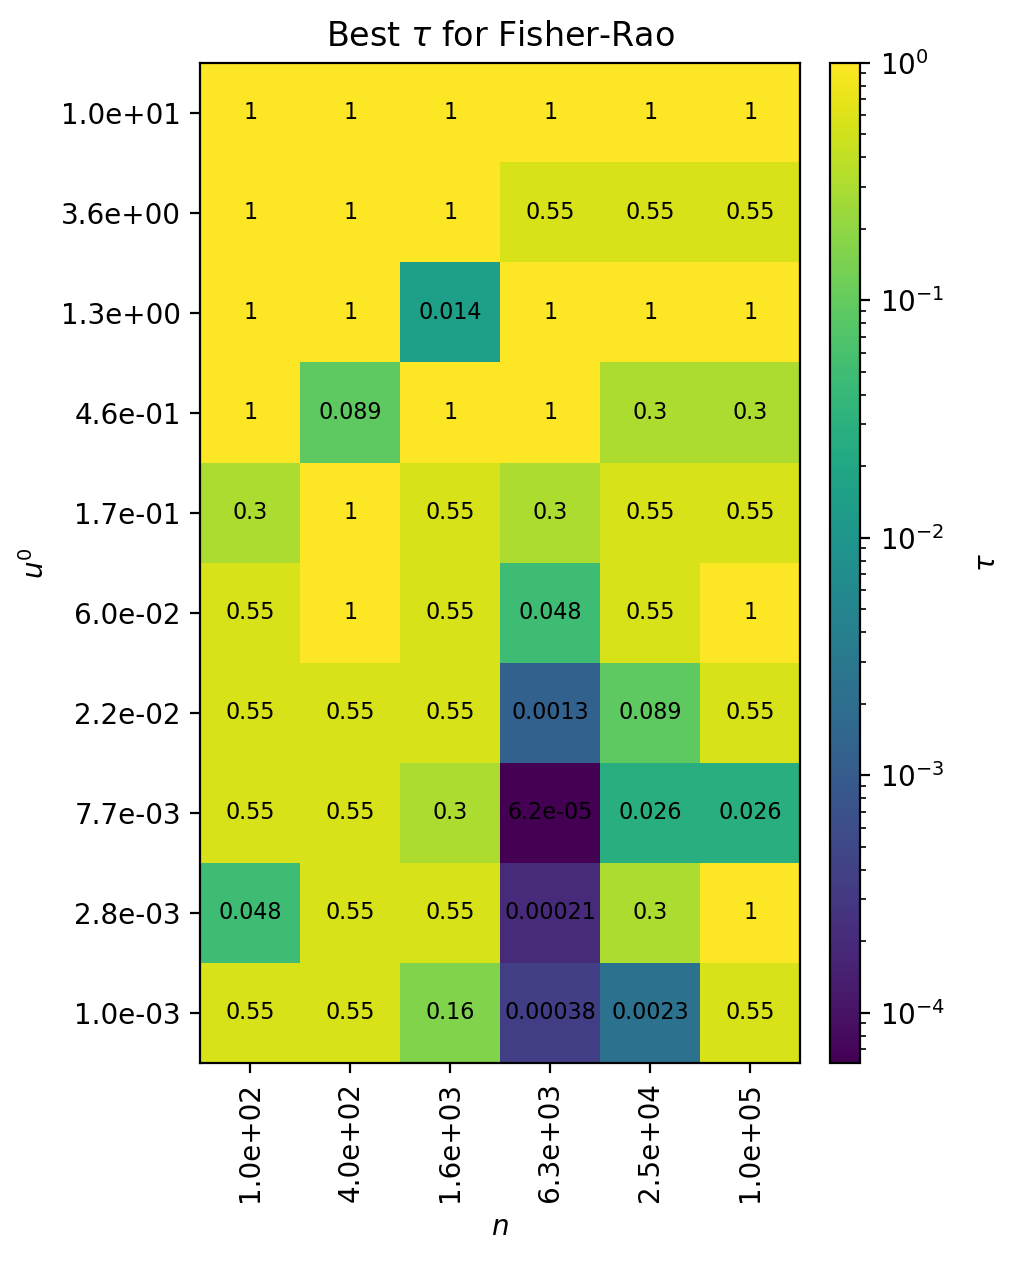

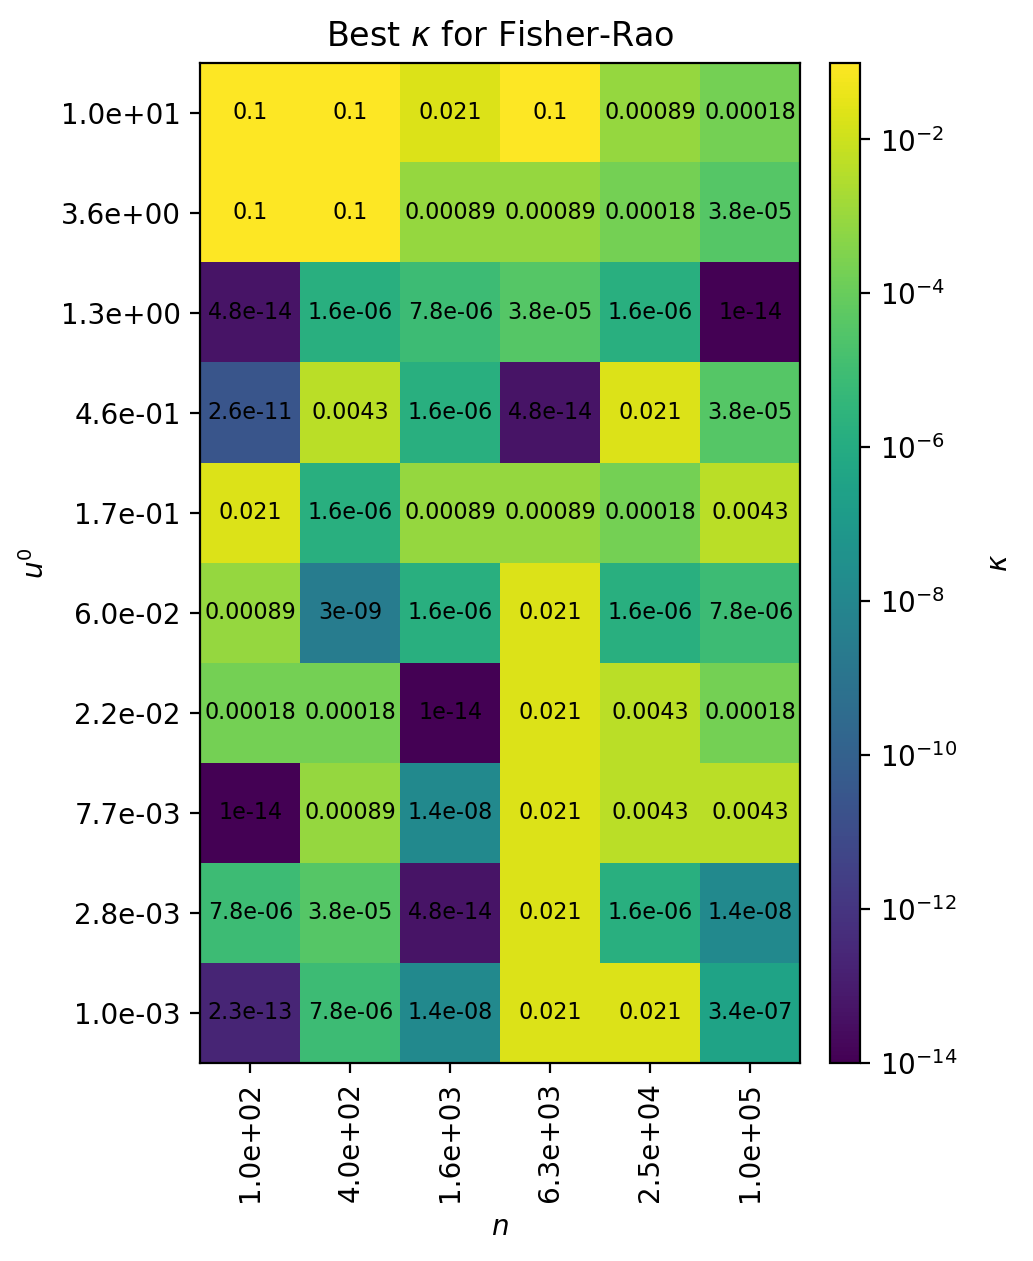

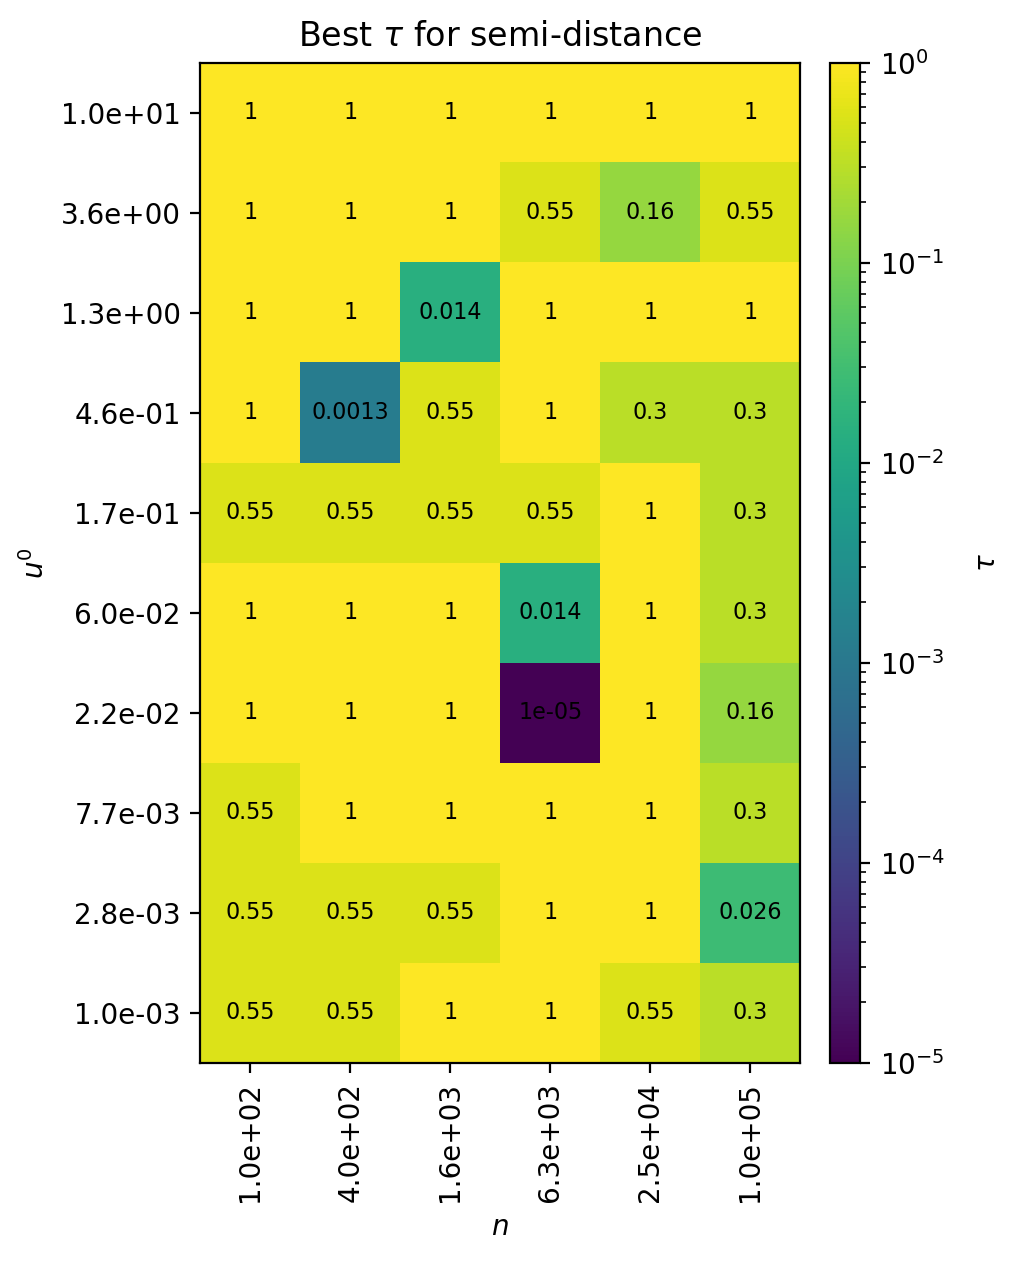

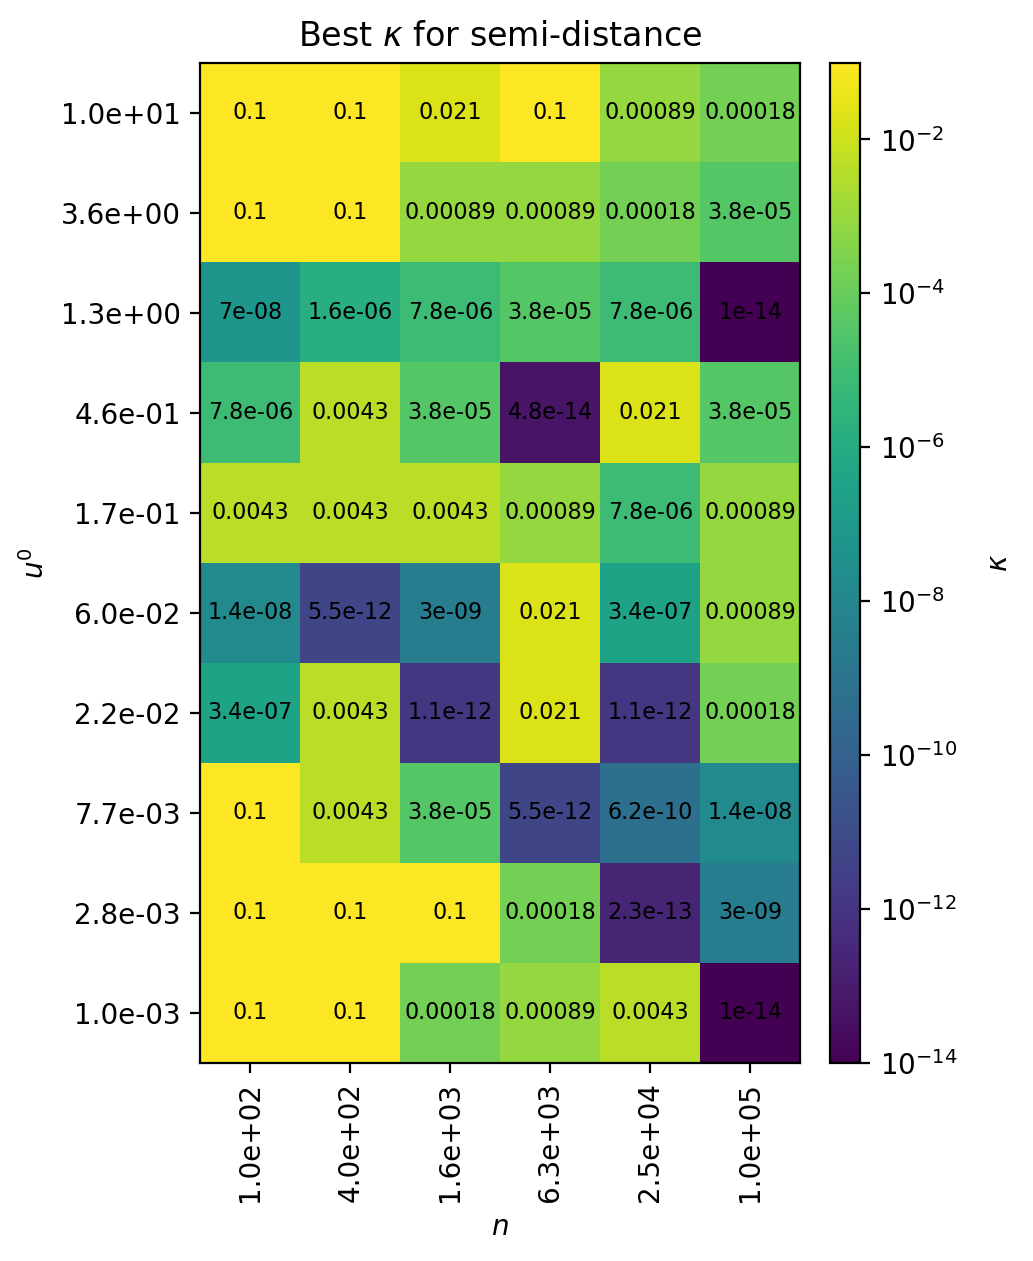

In [23]:
plot_best_tau_kappa(best_results)